In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWF4L2F1bGEtcXVhbnR1bS9jb250ZW50LzA1LWZhc2Vz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap_external.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/codecs.py": 1787687116.7980936, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/aliases.py": 1787687116.852094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/__init__.py": 1787687116.8510938, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/utf_8.py": 1787687116.888094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/abc.py": 1787687116.7790935, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/io.py": 1787687117.0350945, "/home/max/.local/share/uv/python/cpython-3.10-linu

In [2]:
# Importações para visualização da esfera de Bloch
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit.quantum_info import Statevector
from sympy import Matrix, symbols       # Para criar matrizes e símbolos matemáticos
from IPython.display import display, Markdown

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Definir as portas de fase
Z = Matrix([[1, 0],
            [0, -1]])

S = Matrix([[1, 0],
            [0, sp.I]])

T = Matrix([[1, 0],
            [0, sp.exp(sp.I * sp.pi / 4)]])

display(Markdown(f"$$Z = {sp.latex(Z)}$$"))
display(Markdown(f"$$S = {sp.latex(S)}$$"))
display(Markdown(f"$$T = {sp.latex(T)}$$"))

$$Z = \left[\begin{matrix}1 & 0\\0 & -1\end{matrix}\right]$$

$$S = \left[\begin{matrix}1 & 0\\0 & i\end{matrix}\right]$$

$$T = \left[\begin{matrix}1 & 0\\0 & e^{\frac{i \pi}{4}}\end{matrix}\right]$$

Estado |+⟩ (Fase 0°) - Eixo +X:


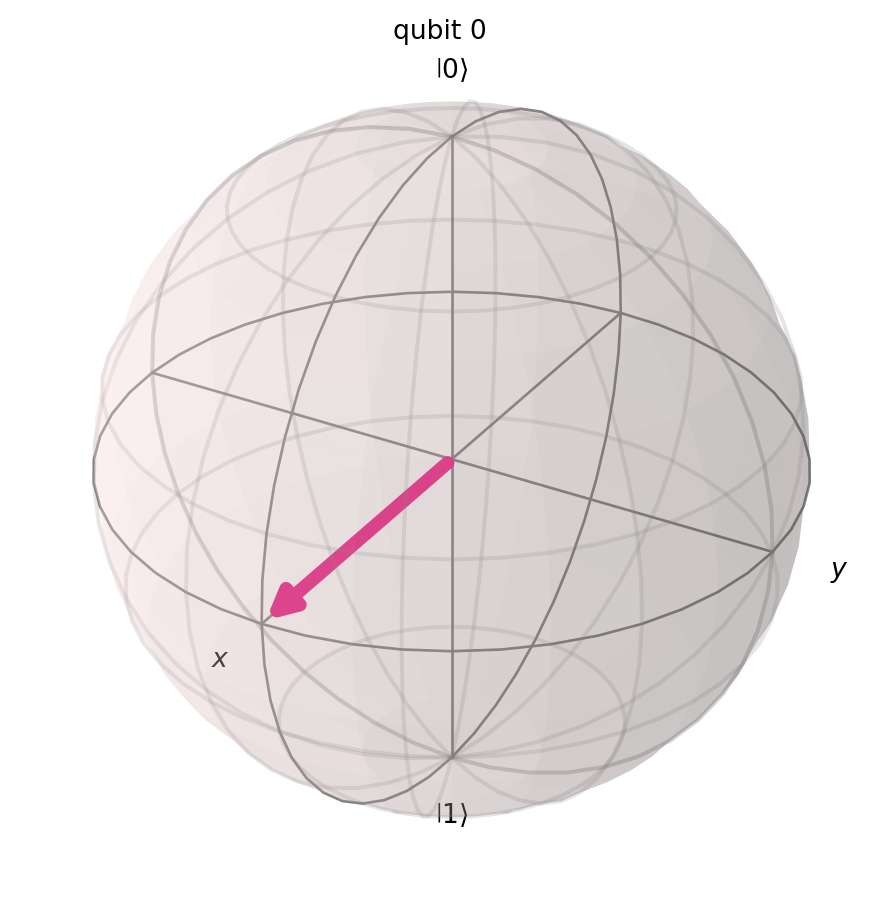


Estado |-⟩ (Fase 180°) - Eixo -X:


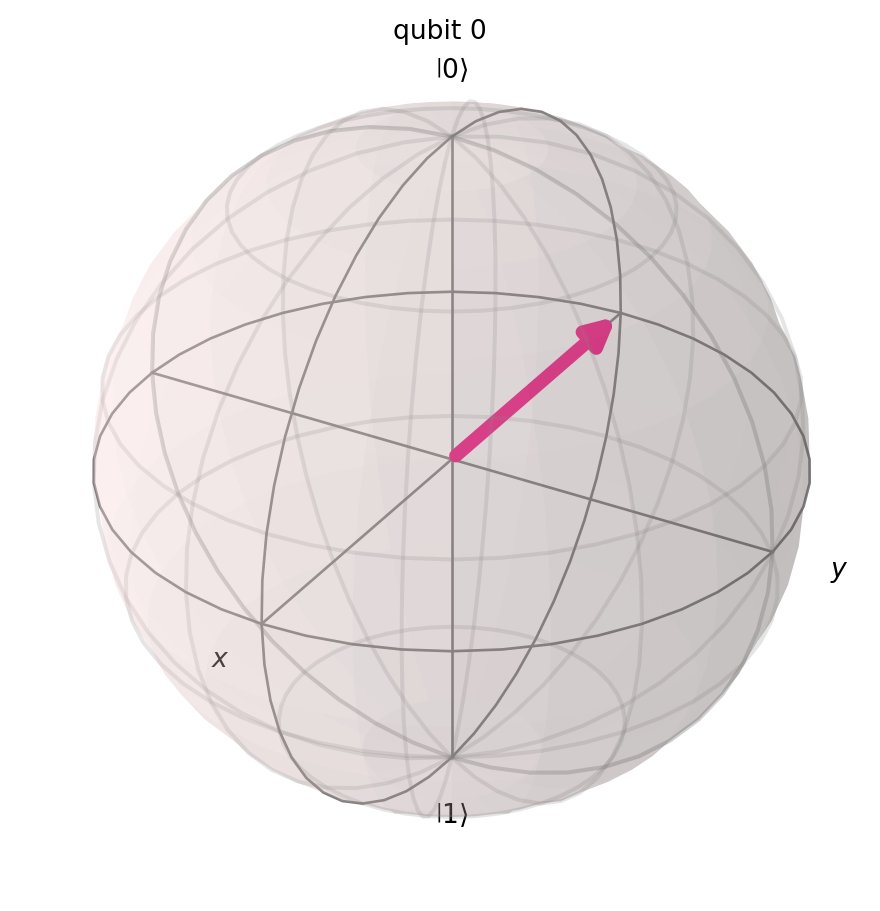


Estado |i+⟩ (Fase 90°) - Eixo +Y:


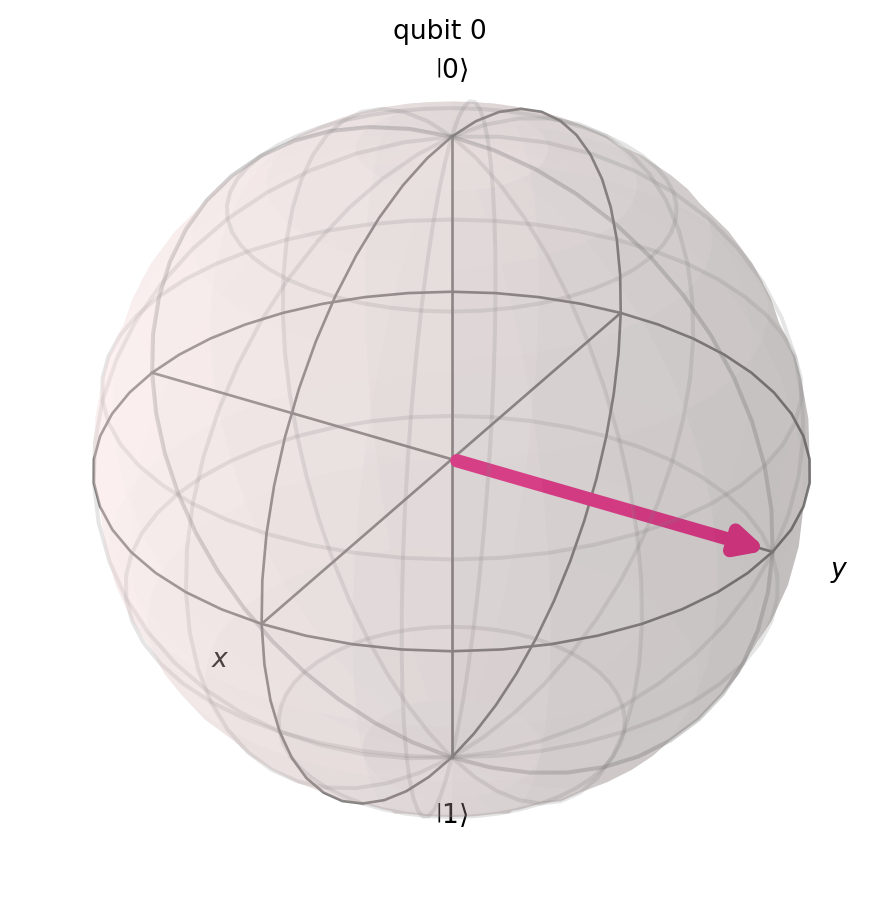


Estado |i-⟩ (Fase 270°) - Eixo -Y:


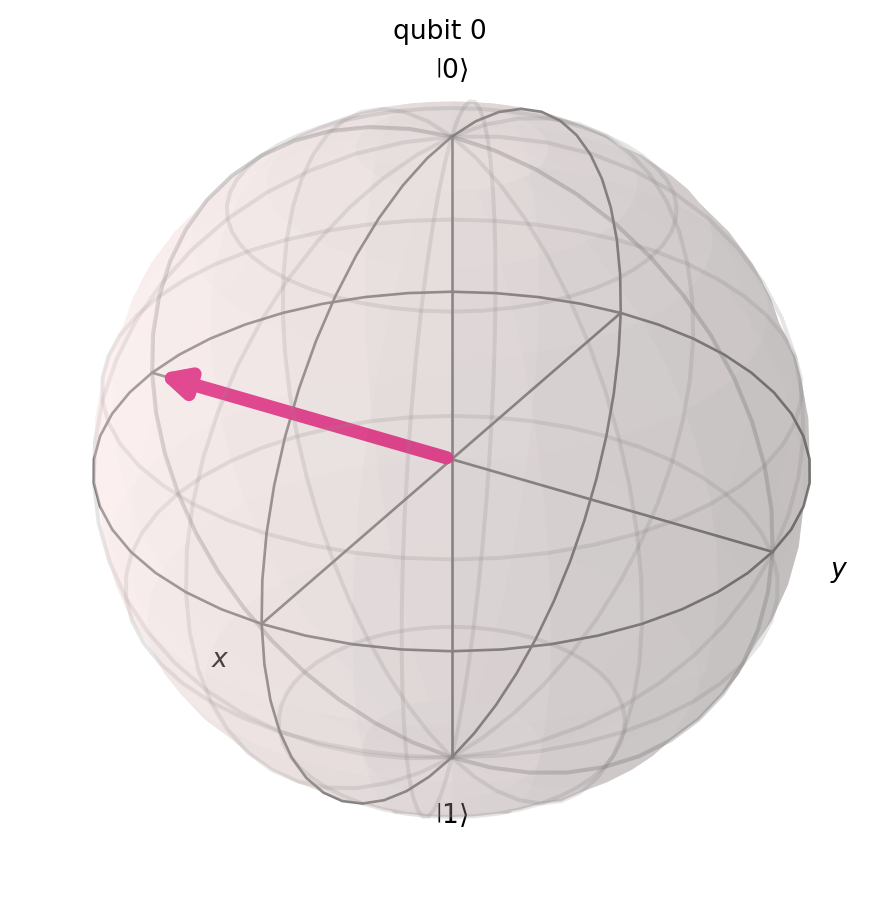


Observe como todos os estados estão no equador da esfera de Bloch
(igual probabilidade de medir 0 ou 1), mas em direções diferentes.


In [3]:
# Statevector do Qiskit serve para visualização. 
# Vai ajudar a montrar a esfera de Bloch.
# Ele aceita listas com os coeficientes dos estados |0⟩ e |1⟩, neste caso
# aqueles alfa e beta que vimos antes.

# Aqui, alfa e beta são ambos 1/√2 para o estado |+⟩

# Estado |+⟩ = H|0⟩ (fase 0°)
state_plus = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])

# Estado |-⟩ = H|1⟩ = Z|+⟩ (fase 180°)
state_minus = Statevector([1/np.sqrt(2), -1/np.sqrt(2)])

# Estado |i+⟩ = S|+⟩ (fase 90°)
state_i_plus = Statevector([1/np.sqrt(2), 1j/np.sqrt(2)])

# Estado |i-⟩ (fase 270°)
state_i_minus = Statevector([1/np.sqrt(2), -1j/np.sqrt(2)])

# Visualizar na esfera de Bloch
print("Estado |+⟩ (Fase 0°) - Eixo +X:")
display(plot_bloch_multivector(state_plus))

print("\nEstado |-⟩ (Fase 180°) - Eixo -X:")
display(plot_bloch_multivector(state_minus))

print("\nEstado |i+⟩ (Fase 90°) - Eixo +Y:")
display(plot_bloch_multivector(state_i_plus))

print("\nEstado |i-⟩ (Fase 270°) - Eixo -Y:")
display(plot_bloch_multivector(state_i_minus))

print("\nObserve como todos os estados estão no equador da esfera de Bloch")
print("(igual probabilidade de medir 0 ou 1), mas em direções diferentes.")

Antes de aplicar a porta Z:


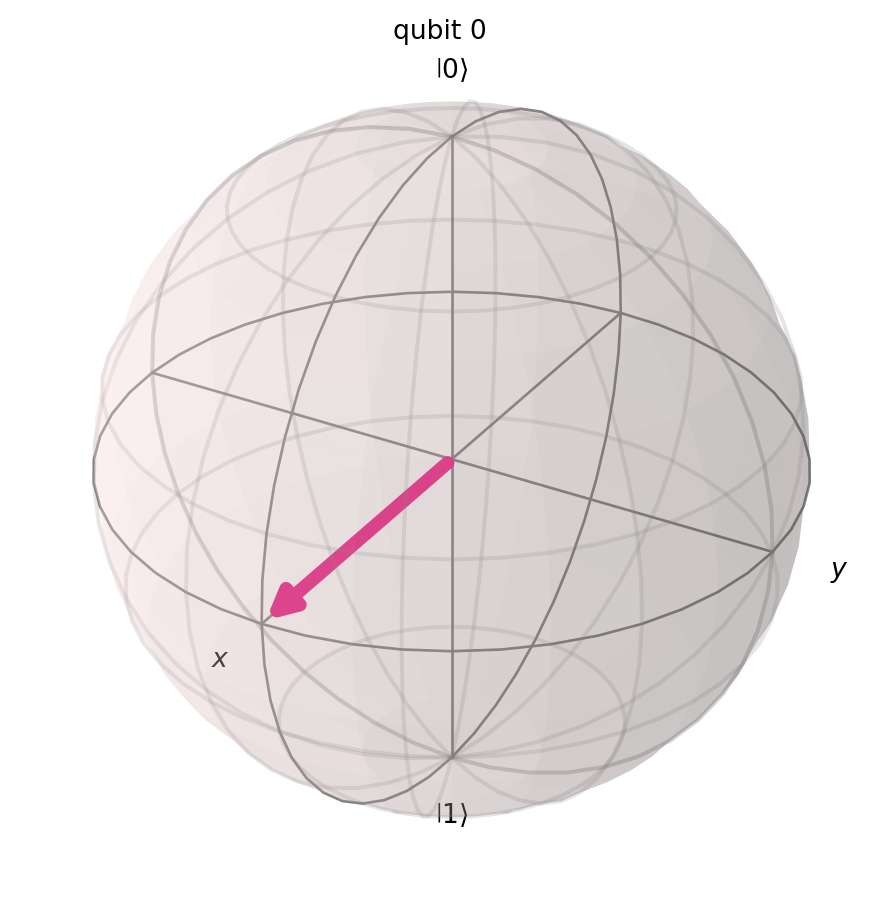


Depois de aplicar a porta Z:


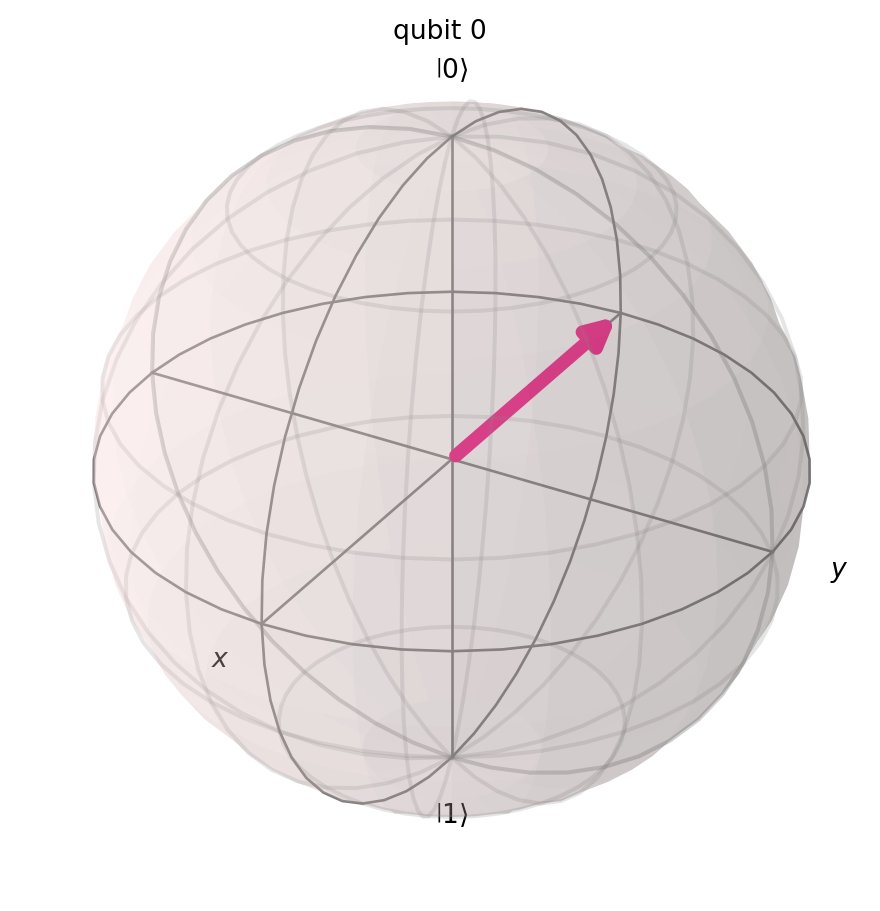


A porta Z rotacionou o estado de +X para -X (180° em torno do eixo Z)


In [4]:
# Demonstração: Aplicar porta Z em |+⟩
estado_inicial = state_plus
estado_apos_Z = Statevector([1/np.sqrt(2), -1/np.sqrt(2)])

print("Antes de aplicar a porta Z:")
display(plot_bloch_multivector(estado_inicial))

print("\nDepois de aplicar a porta Z:")
display(plot_bloch_multivector(estado_apos_Z))

print("\nA porta Z rotacionou o estado de +X para -X (180° em torno do eixo Z)")

Antes de aplicar a porta S:


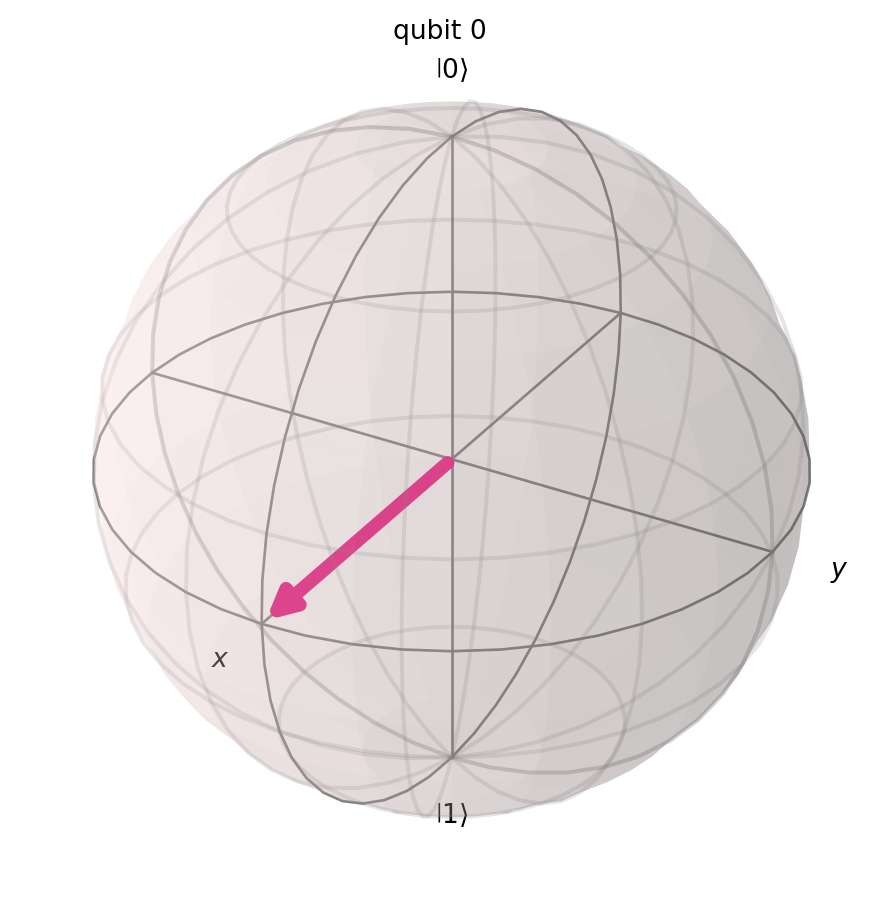


Depois de aplicar a porta S:


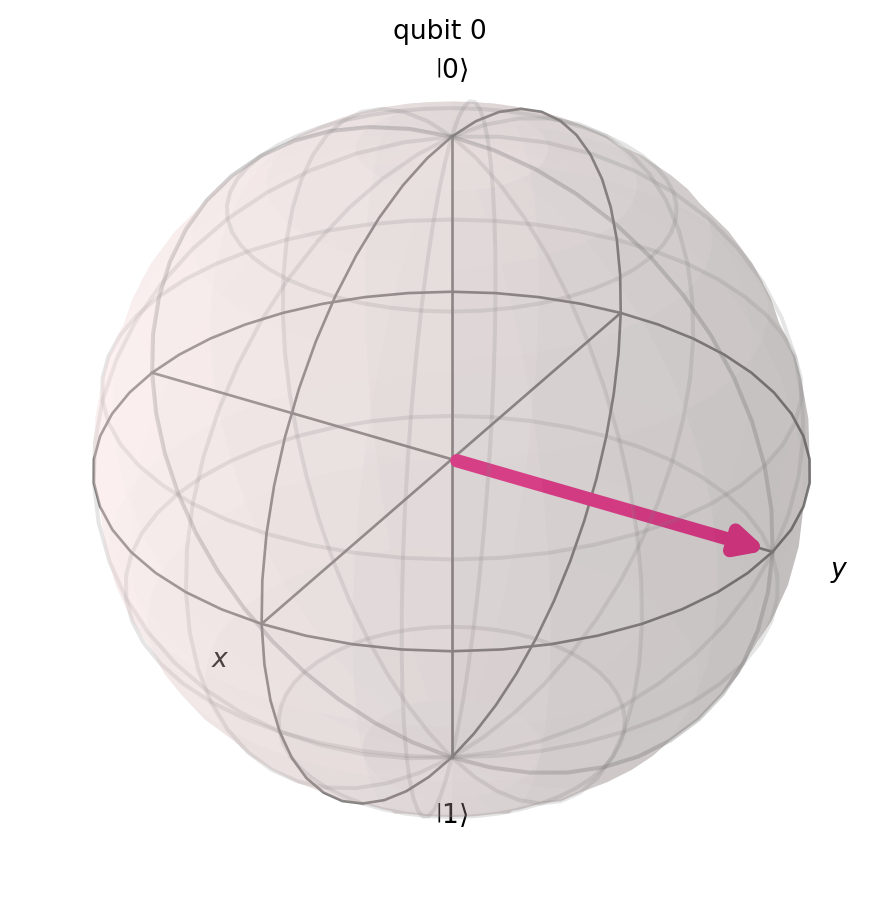


A porta S rotacionou o estado de +X para +Y (90° em torno do eixo Z)


In [5]:
# Demonstração: Aplicar porta S em |+⟩
estado_inicial = state_plus
estado_apos_S = Statevector([1/np.sqrt(2), 1j/np.sqrt(2)])

print("Antes de aplicar a porta S:")
display(plot_bloch_multivector(estado_inicial))

print("\nDepois de aplicar a porta S:")
display(plot_bloch_multivector(estado_apos_S))

print("\nA porta S rotacionou o estado de +X para +Y (90° em torno do eixo Z)")

Estado |+⟩ - Fase 0°:


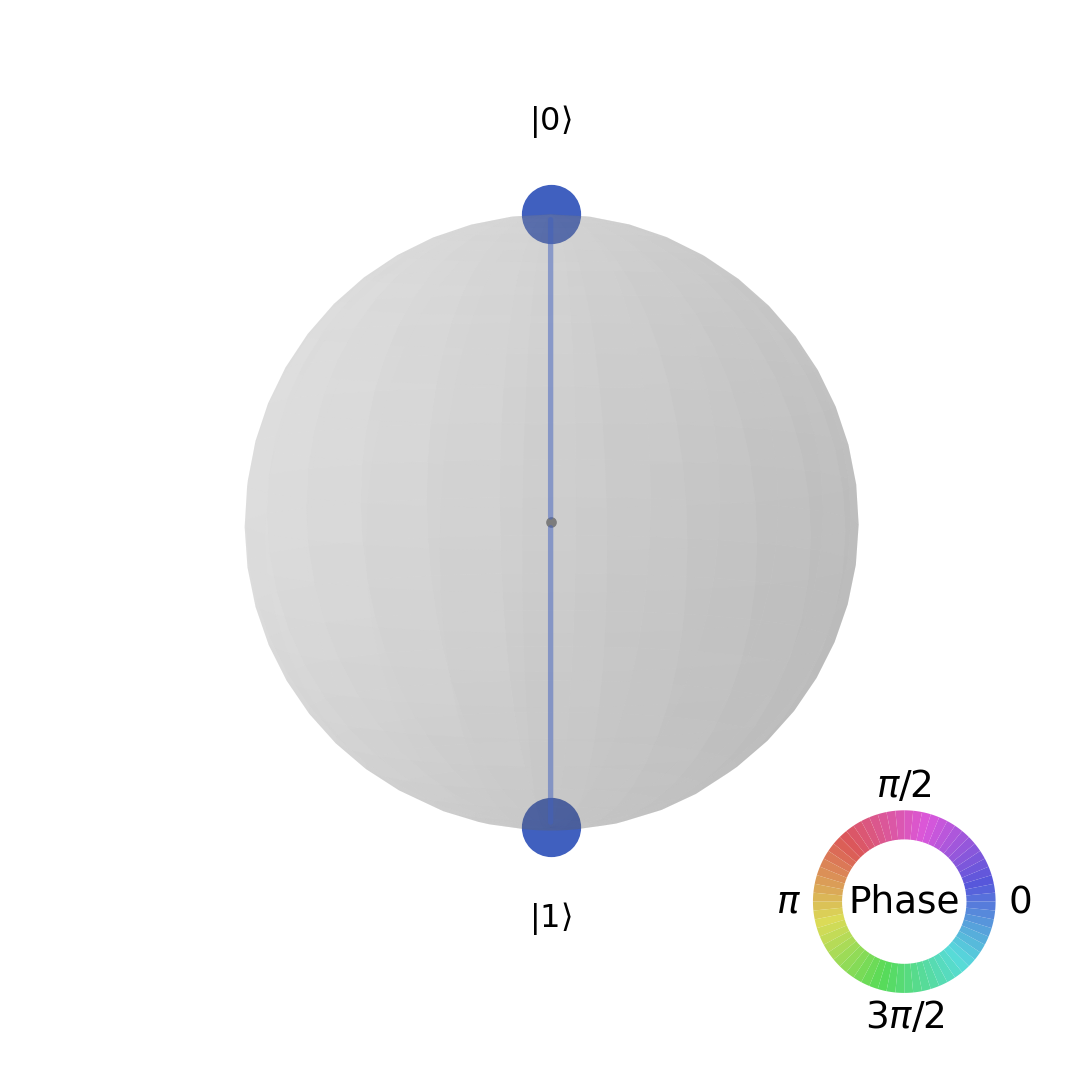


Estado |-⟩ - Fase 180°:


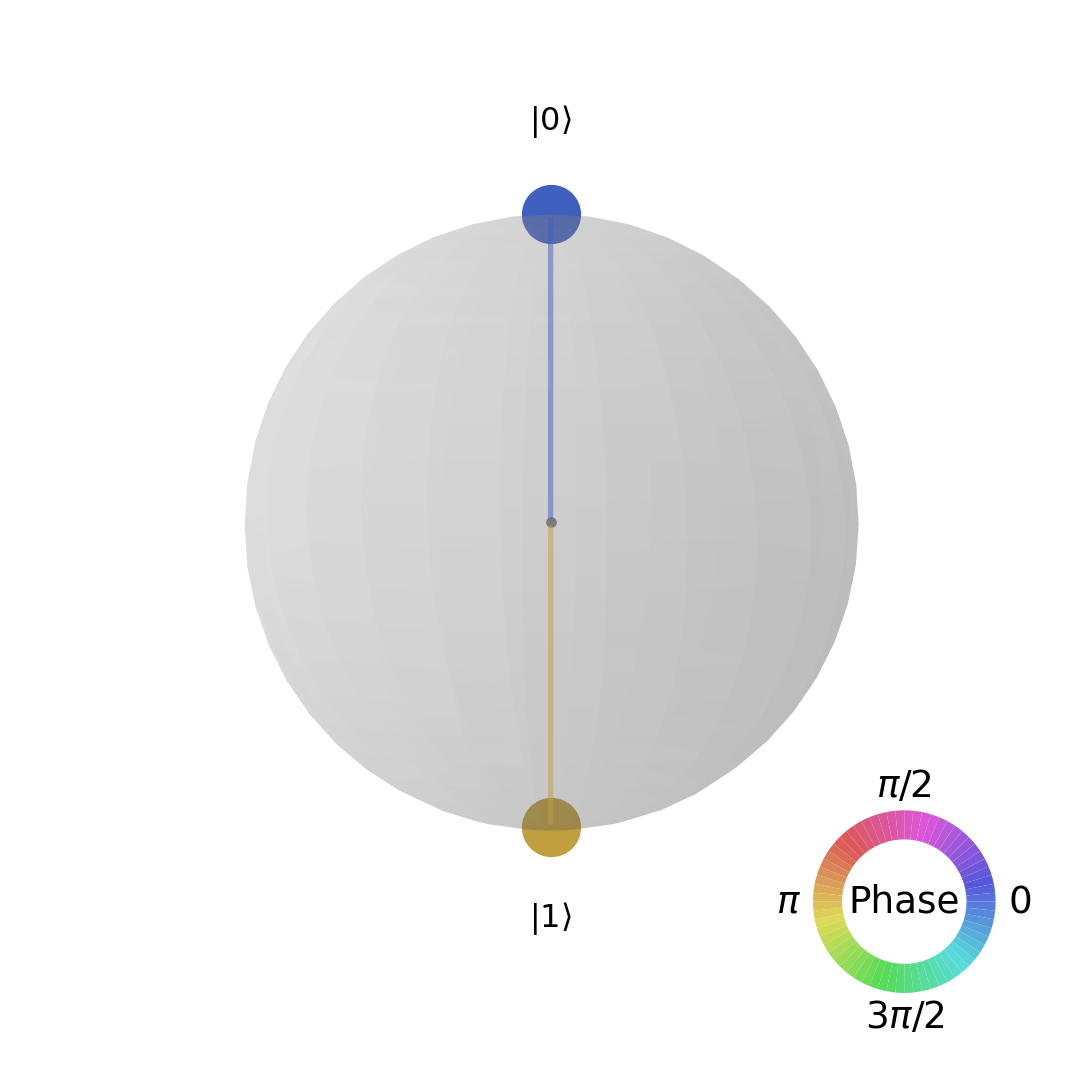


Estado |i+⟩ - Fase 90°:


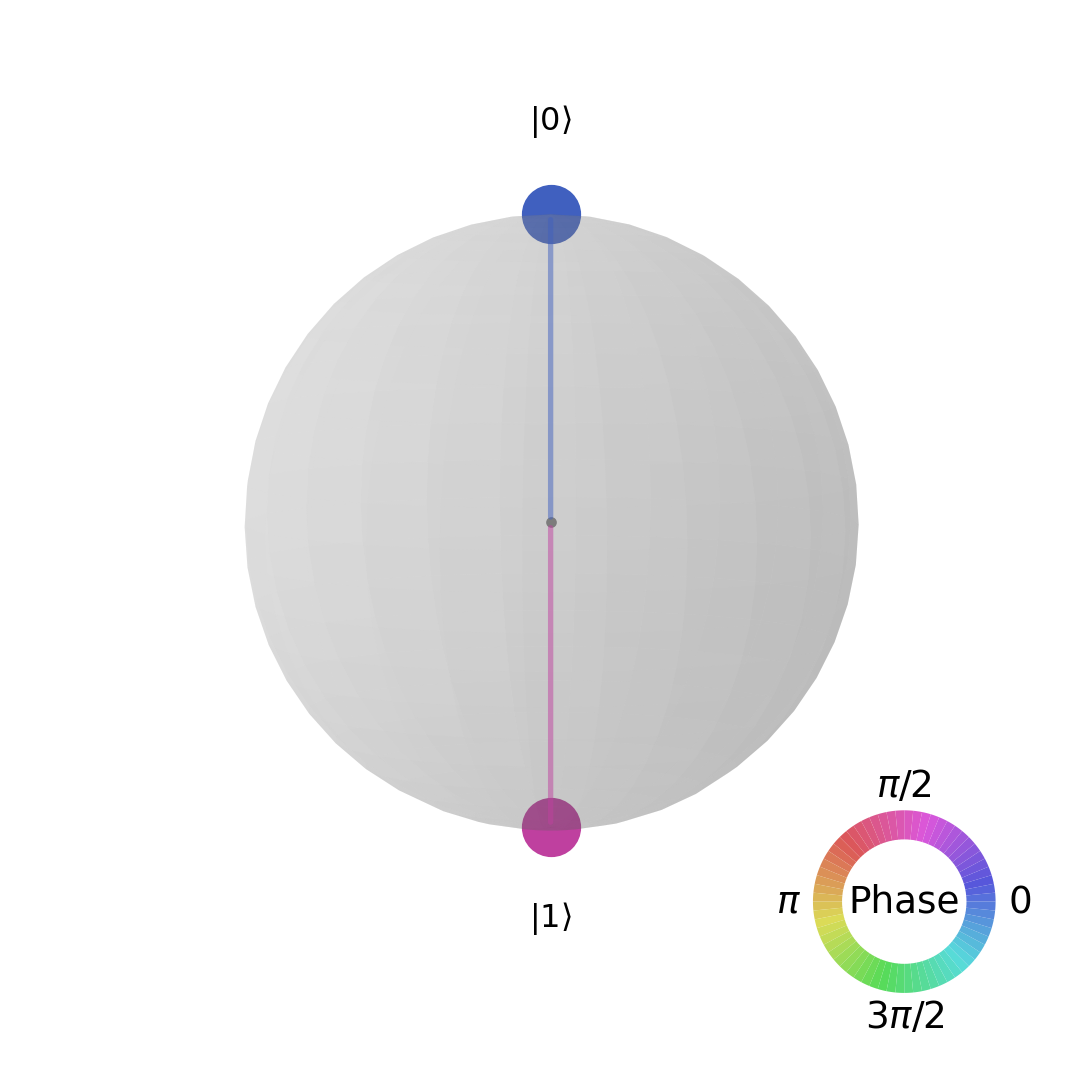


Estado |i-⟩ - Fase 270°:


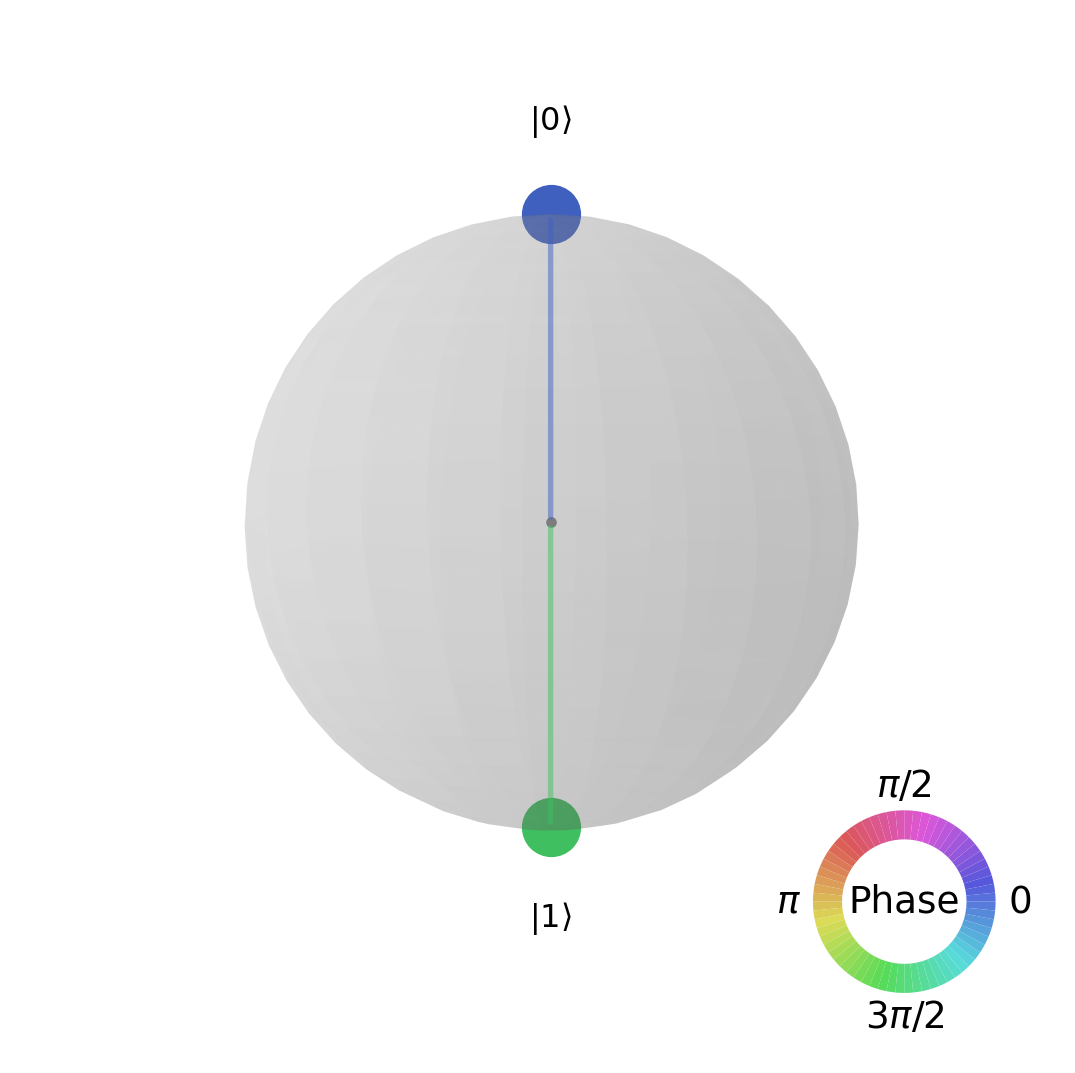


No Q-Sphere, observe a mudança de cores indicando diferentes fases.


In [6]:
# Visualizar os mesmos estados no Q-Sphere
print("Estado |+⟩ - Fase 0°:")
display(plot_state_qsphere(state_plus))

print("\nEstado |-⟩ - Fase 180°:")
display(plot_state_qsphere(state_minus))

print("\nEstado |i+⟩ - Fase 90°:")
display(plot_state_qsphere(state_i_plus))

print("\nEstado |i-⟩ - Fase 270°:")
display(plot_state_qsphere(state_i_minus))

print("\nNo Q-Sphere, observe a mudança de cores indicando diferentes fases.")

Estado criado: |ψ⟩ = 1/√2 (|0⟩ + e^(i·45°)|1⟩)
Componente |0⟩: (0.7071067811865475+0j)
Componente |1⟩: (0.5+0.4999999999999999j)
Fase relativa: 45°

Esfera de Bloch - Fase θ = 45°:


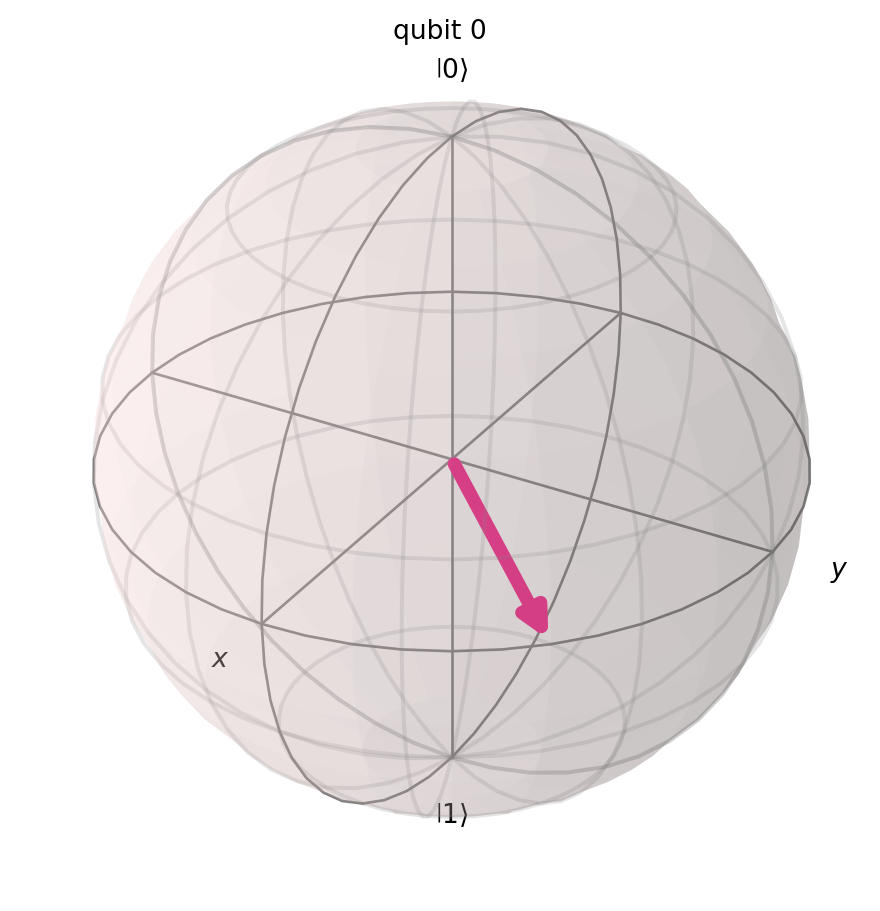


Q-Sphere - Fase θ = 45°:


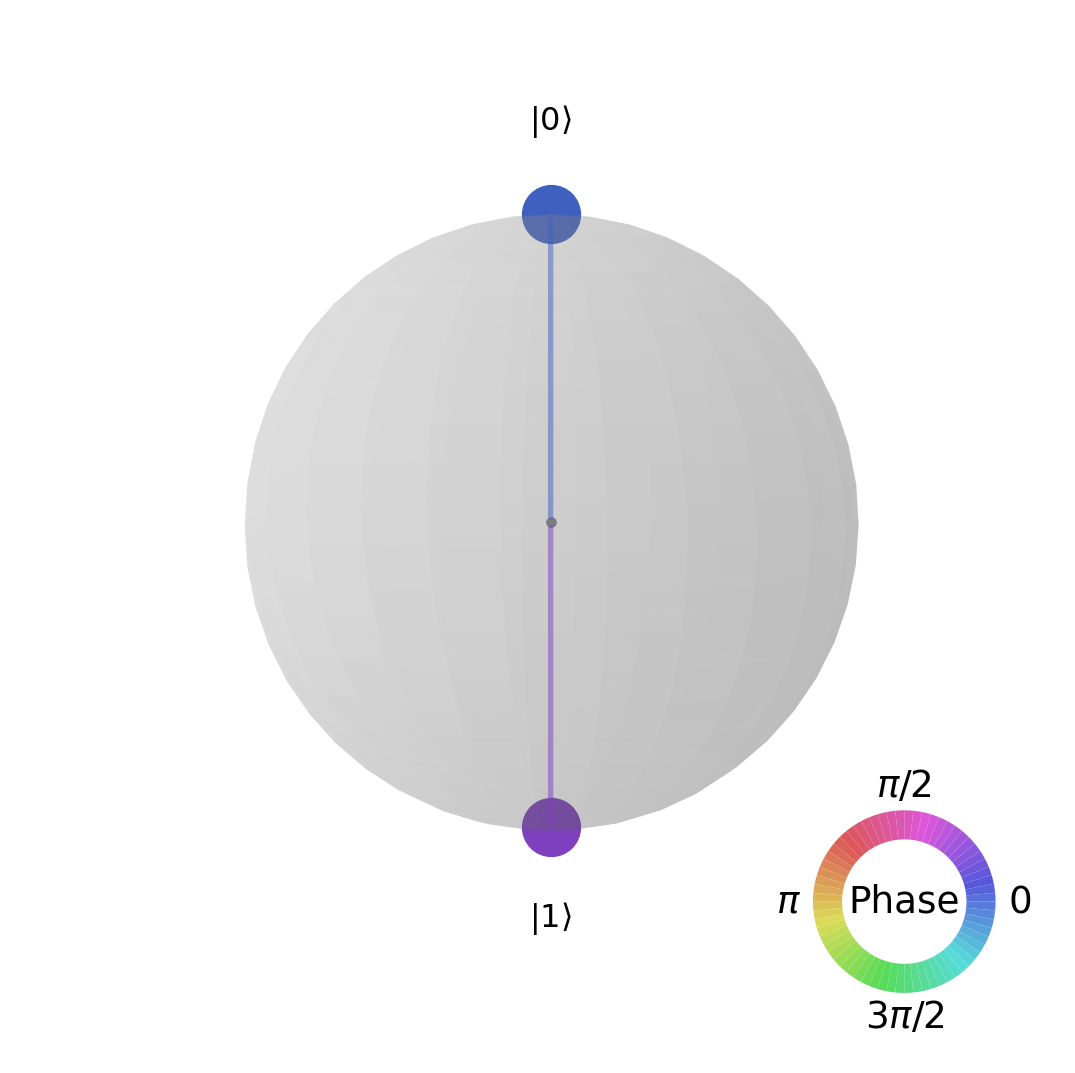

In [7]:
# Experimente diferentes valores de theta (em graus)
theta_graus = 45  # Modifique este valor: 0, 45, 90, 135, 180, 225, 270, 315...
theta_rad = np.deg2rad(theta_graus)

# Criar estado com fase customizada
estado_custom = Statevector([1/np.sqrt(2), np.exp(1j * theta_rad)/np.sqrt(2)])

# Mostrar o estado matematicamente
print(f"Estado criado: |ψ⟩ = 1/√2 (|0⟩ + e^(i·{theta_graus}°)|1⟩)")
print(f"Componente |0⟩: {estado_custom.data[0]}")
print(f"Componente |1⟩: {estado_custom.data[1]}")
print(f"Fase relativa: {theta_graus}°\n")

# Visualizar na Esfera de Bloch
print(f"Esfera de Bloch - Fase θ = {theta_graus}°:")
display(plot_bloch_multivector(estado_custom))

# Visualizar no Q-Sphere
print(f"\nQ-Sphere - Fase θ = {theta_graus}°:")
display(plot_state_qsphere(estado_custom))  

In [8]:
# Definir as portas de rotação parametrizadas
import numpy as np
import sympy as sp
from sympy import Matrix, symbols, cos, sin, exp, I, pi, latex
from IPython.display import display, Markdown

# Definir o símbolo theta
theta = symbols('theta', real=True)

# Porta RX(θ) - Rotação em torno do eixo X
RX = Matrix([
    [cos(theta/2), -I*sin(theta/2)],
    [-I*sin(theta/2), cos(theta/2)]
])

# Porta RY(θ) - Rotação em torno do eixo Y  
RY = Matrix([
    [cos(theta/2), -sin(theta/2)],
    [sin(theta/2), cos(theta/2)]
])

# Porta RZ(θ) - Rotação em torno do eixo Z
RZ = Matrix([
    [exp(-I*theta/2), 0],
    [0, exp(I*theta/2)]
])

display(Markdown(f"### Matrizes das Portas de Rotação"))
display(Markdown(f"**RX(θ)** - Rotação no eixo X:"))
display(Markdown(f"$$ RX(\\theta) = {latex(RX)} $$"))
display(Markdown(f"**RY(θ)** - Rotação no eixo Y:"))
display(Markdown(f"$$ RY(\\theta) = {latex(RY)} $$"))
display(Markdown(f"**RZ(θ)** - Rotação no eixo Z:"))
display(Markdown(f"$$ RZ(\\theta) = {latex(RZ)} $$"))

### Matrizes das Portas de Rotação

**RX(θ)** - Rotação no eixo X:

$$ RX(\theta) = \left[\begin{matrix}\cos{\left(\frac{\theta}{2} \right)} & - i \sin{\left(\frac{\theta}{2} \right)}\\- i \sin{\left(\frac{\theta}{2} \right)} & \cos{\left(\frac{\theta}{2} \right)}\end{matrix}\right] $$

**RY(θ)** - Rotação no eixo Y:

$$ RY(\theta) = \left[\begin{matrix}\cos{\left(\frac{\theta}{2} \right)} & - \sin{\left(\frac{\theta}{2} \right)}\\\sin{\left(\frac{\theta}{2} \right)} & \cos{\left(\frac{\theta}{2} \right)}\end{matrix}\right] $$

**RZ(θ)** - Rotação no eixo Z:

$$ RZ(\theta) = \left[\begin{matrix}e^{- \frac{i \theta}{2}} & 0\\0 & e^{\frac{i \theta}{2}}\end{matrix}\right] $$

PORTA RY: Rotação em torno do eixo Y

0° (θ = 0.0000 rad):
  RY(0.0000)|0⟩ = 1.0000+0.0000j|0⟩ + 0.0000+0.0000j|1⟩
  Probabilidades: P(0) = 1.0000, P(1) = 0.0000

45° (θ = 0.7854 rad):
  RY(0.7854)|0⟩ = 0.9239+0.0000j|0⟩ + 0.3827+0.0000j|1⟩
  Probabilidades: P(0) = 0.8536, P(1) = 0.1464



90° (θ = 1.5708 rad):
  RY(1.5708)|0⟩ = 0.7071+0.0000j|0⟩ + 0.7071+0.0000j|1⟩
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000



135° (θ = 2.3562 rad):
  RY(2.3562)|0⟩ = 0.3827+0.0000j|0⟩ + 0.9239+0.0000j|1⟩
  Probabilidades: P(0) = 0.1464, P(1) = 0.8536

180° (θ = 3.1416 rad):
  RY(3.1416)|0⟩ = 0.0000+0.0000j|0⟩ + 1.0000+0.0000j|1⟩
  Probabilidades: P(0) = 0.0000, P(1) = 1.0000


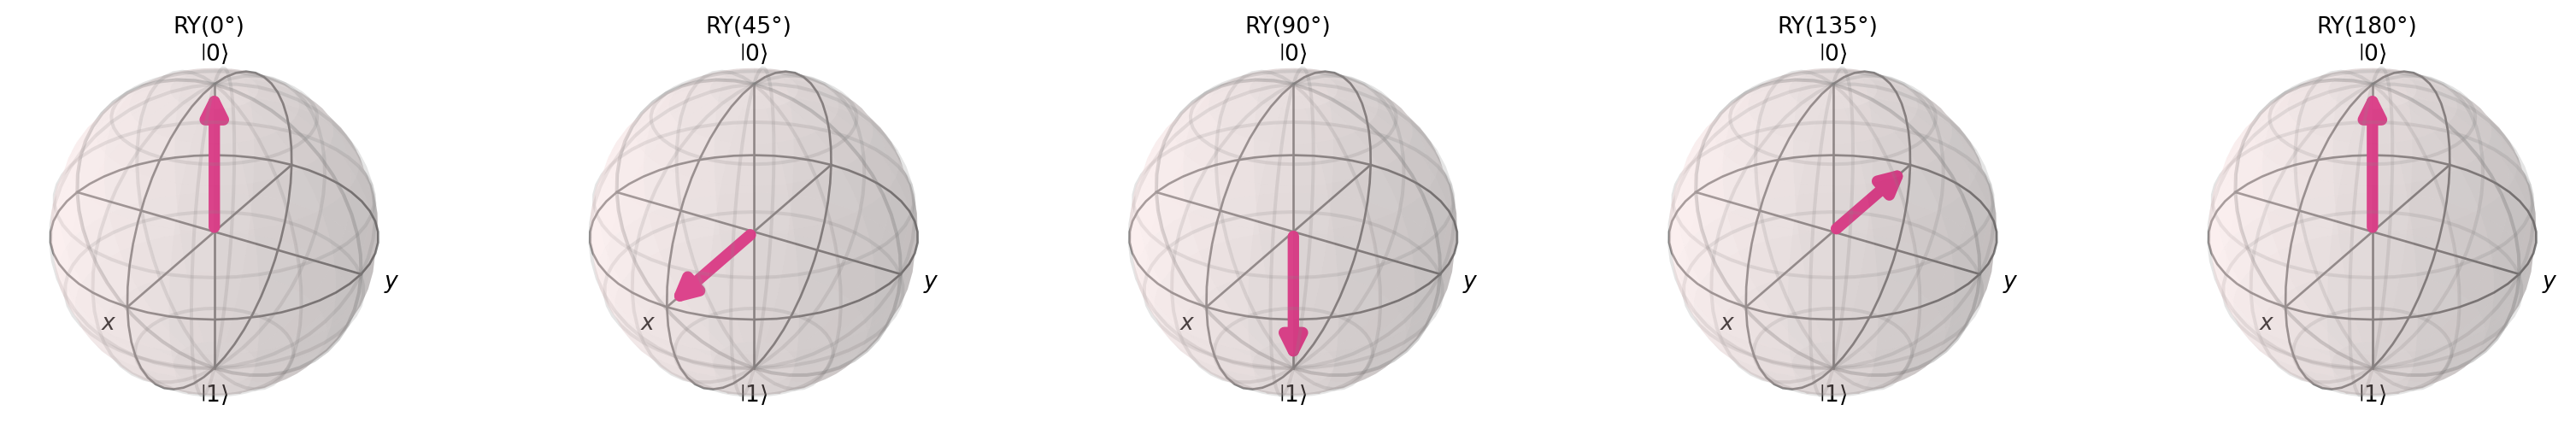


Observações:
  • RY(0°) = |0⟩ (polo norte)
  • RY(90°) = |+⟩ (equador)
  • RY(180°) = |1⟩ (polo sul)
  • Todos os estados estão no plano XZ (y = 0)


In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

# Testar RY com diferentes ângulos
angulos = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
nomes = ['0°', '45°', '90°', '135°', '180°']

print("=" * 70)
print("PORTA RY: Rotação em torno do eixo Y")
print("=" * 70)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={'projection': '3d'})

for i, (angulo, nome) in enumerate(zip(angulos, nomes)):
    # Criar circuito
    qc = QuantumCircuit(1)
    qc.ry(angulo, 0)
    
    # Obter estado
    state = Statevector(qc)
    
    # Calcular amplitudes
    alpha = state.data[0]
    beta = state.data[1]
    
    print(f"\n{nome} (θ = {angulo:.4f} rad):")
    print(f"  RY({angulo:.4f})|0⟩ = {alpha:.4f}|0⟩ + {beta:.4f}|1⟩")
    print(f"  Probabilidades: P(0) = {abs(alpha)**2:.4f}, P(1) = {abs(beta)**2:.4f}")
    
    # Plotar na Esfera de Bloch
    from qiskit.visualization import plot_bloch_vector
    
    # Converter estado em coordenadas de Bloch
    theta_bloch = 2 * angulo  # Dobrar o ângulo para coordenadas de Bloch
    x = np.sin(theta_bloch)
    y = 0  # RY mantém y=0 (rotação no plano XZ)
    z = np.cos(theta_bloch)
    
    plot_bloch_vector([x, y, z], ax=axes[i], title=f'RY({nome})')

plt.subplots_adjust(wspace=0.4)
plt.show()

print("\n" + "=" * 70)
print("Observações:")
print("  • RY(0°) = |0⟩ (polo norte)")
print("  • RY(90°) = |+⟩ (equador)")  
print("  • RY(180°) = |1⟩ (polo sul)")
print("  • Todos os estados estão no plano XZ (y = 0)")
print("=" * 70)

PORTA RZ: Rotação em torno do eixo Z (afeta apenas a fase)

Estado inicial: |+⟩ = H|0⟩
  |+⟩ = 0.7071+0.0000j|0⟩ + 0.7071+0.0000j|1⟩

0° (θ = 0.0000 rad):
  RZ(0.0000)|+⟩ = 0.7071+0.0000j|0⟩ + 0.7071+0.0000j|1⟩
  Fase de |1⟩: 0.00°
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000



90° (θ = 1.5708 rad):
  RZ(1.5708)|+⟩ = 0.5000-0.5000j|0⟩ + 0.5000+0.5000j|1⟩
  Fase de |1⟩: 45.00°
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000



180° (θ = 3.1416 rad):
  RZ(3.1416)|+⟩ = 0.0000-0.7071j|0⟩ + 0.0000+0.7071j|1⟩
  Fase de |1⟩: 90.00°
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000

270° (θ = 4.7124 rad):
  RZ(4.7124)|+⟩ = -0.5000-0.5000j|0⟩ + -0.5000+0.5000j|1⟩
  Fase de |1⟩: 135.00°
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000

360° (θ = 6.2832 rad):
  RZ(6.2832)|+⟩ = -0.7071-0.0000j|0⟩ + -0.7071+0.0000j|1⟩
  Fase de |1⟩: 180.00°
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000


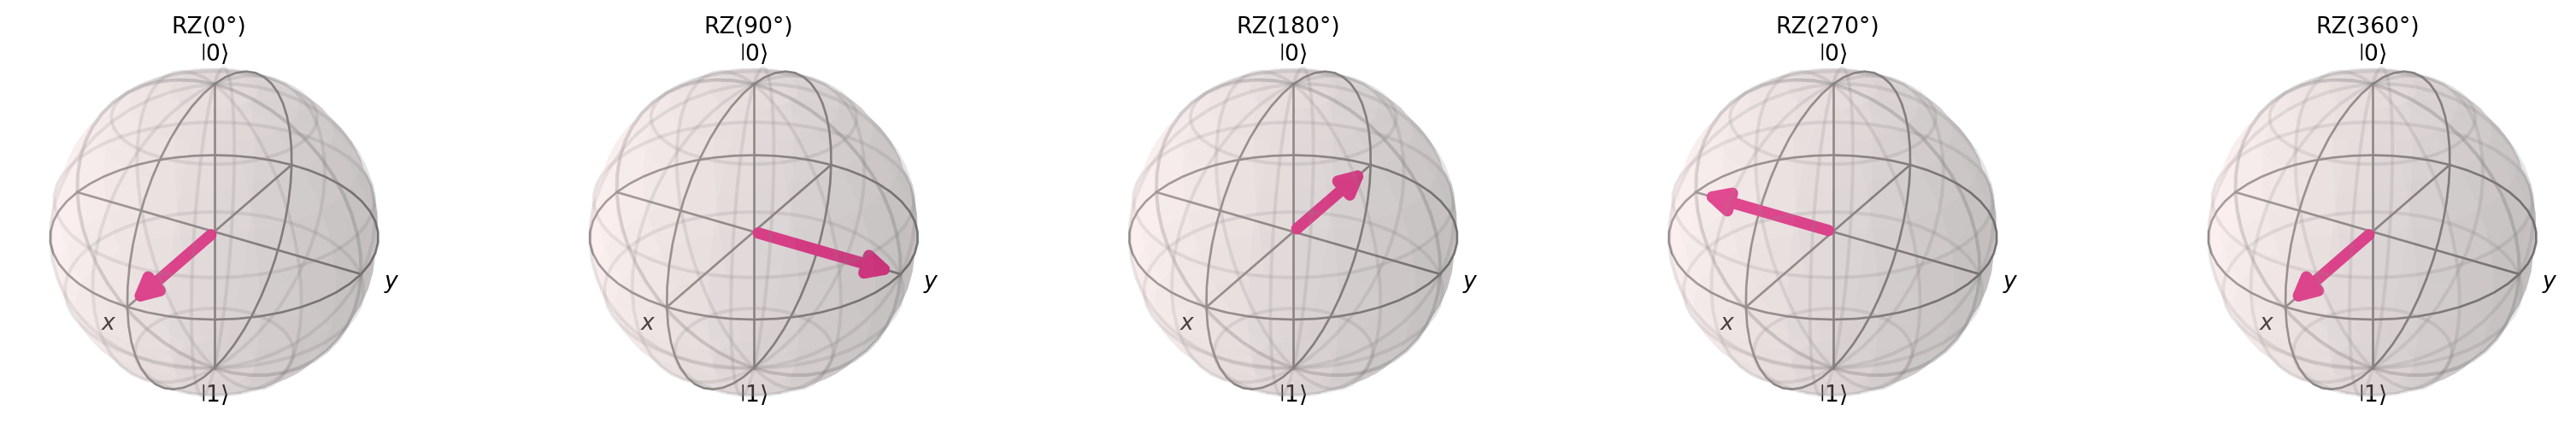


Observações importantes:
  • As PROBABILIDADES não mudam (sempre 50%-50%)
  • O qubit permanece no EQUADOR da esfera
  • Apenas a FASE (direção no equador) muda
  • RZ(0°) = |+⟩, RZ(180°) = |-⟩


In [10]:
# Demonstração: RZ aplicado a |+⟩
print("=" * 70)
print("PORTA RZ: Rotação em torno do eixo Z (afeta apenas a fase)")
print("=" * 70)

# Primeiro criar |+⟩
qc_base = QuantumCircuit(1)
qc_base.h(0)  # Hadamard cria |+⟩
state_plus = Statevector(qc_base)

print("\nEstado inicial: |+⟩ = H|0⟩")
print(f"  |+⟩ = {state_plus.data[0]:.4f}|0⟩ + {state_plus.data[1]:.4f}|1⟩")

# Testar RZ com diferentes ângulos
angulos_rz = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
nomes_rz = ['0°', '90°', '180°', '270°', '360°']

fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={'projection': '3d'})

for i, (angulo, nome) in enumerate(zip(angulos_rz, nomes_rz)):
    qc = QuantumCircuit(1)
    qc.h(0)  # Criar |+⟩
    qc.rz(angulo, 0)  # Aplicar RZ
    
    state = Statevector(qc)
    alpha = state.data[0]
    beta = state.data[1]
    
    # Fase do componente |1⟩
    fase_beta = np.angle(beta, deg=True)
    
    print(f"\n{nome} (θ = {angulo:.4f} rad):")
    print(f"  RZ({angulo:.4f})|+⟩ = {alpha:.4f}|0⟩ + {beta:.4f}|1⟩")
    print(f"  Fase de |1⟩: {fase_beta:.2f}°")
    print(f"  Probabilidades: P(0) = {abs(alpha)**2:.4f}, P(1) = {abs(beta)**2:.4f}")
    
    # Coordenadas de Bloch
    x = 2 * (alpha.conjugate() * beta).real
    y = 2 * (alpha.conjugate() * beta).imag
    z = abs(alpha)**2 - abs(beta)**2
    
    plot_bloch_vector([x, y, z], ax=axes[i], title=f'RZ({nome})')

plt.subplots_adjust(wspace=0.4)
plt.show()

print("\n" + "=" * 70)
print("Observações importantes:")
print("  • As PROBABILIDADES não mudam (sempre 50%-50%)")
print("  • O qubit permanece no EQUADOR da esfera")
print("  • Apenas a FASE (direção no equador) muda")
print("  • RZ(0°) = |+⟩, RZ(180°) = |-⟩")
print("=" * 70)

PORTA RX: Rotação em torno do eixo X

0° (θ = 0.0000 rad):
  RX(0.0000)|0⟩ = (1+0j)|0⟩ + 0j|1⟩
  Probabilidades: P(0) = 1.0000, P(1) = 0.0000



90° (θ = 1.5708 rad):
  RX(1.5708)|0⟩ = (0.7071067811865476+0j)|0⟩ + -0.7071067811865475j|1⟩
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000

180° (θ = 3.1416 rad):
  RX(3.1416)|0⟩ = (6.123233995736766e-17+0j)|0⟩ + -1j|1⟩
  Probabilidades: P(0) = 0.0000, P(1) = 1.0000



270° (θ = 4.7124 rad):
  RX(4.7124)|0⟩ = (-0.7071067811865475+0j)|0⟩ + -0.7071067811865476j|1⟩
  Probabilidades: P(0) = 0.5000, P(1) = 0.5000


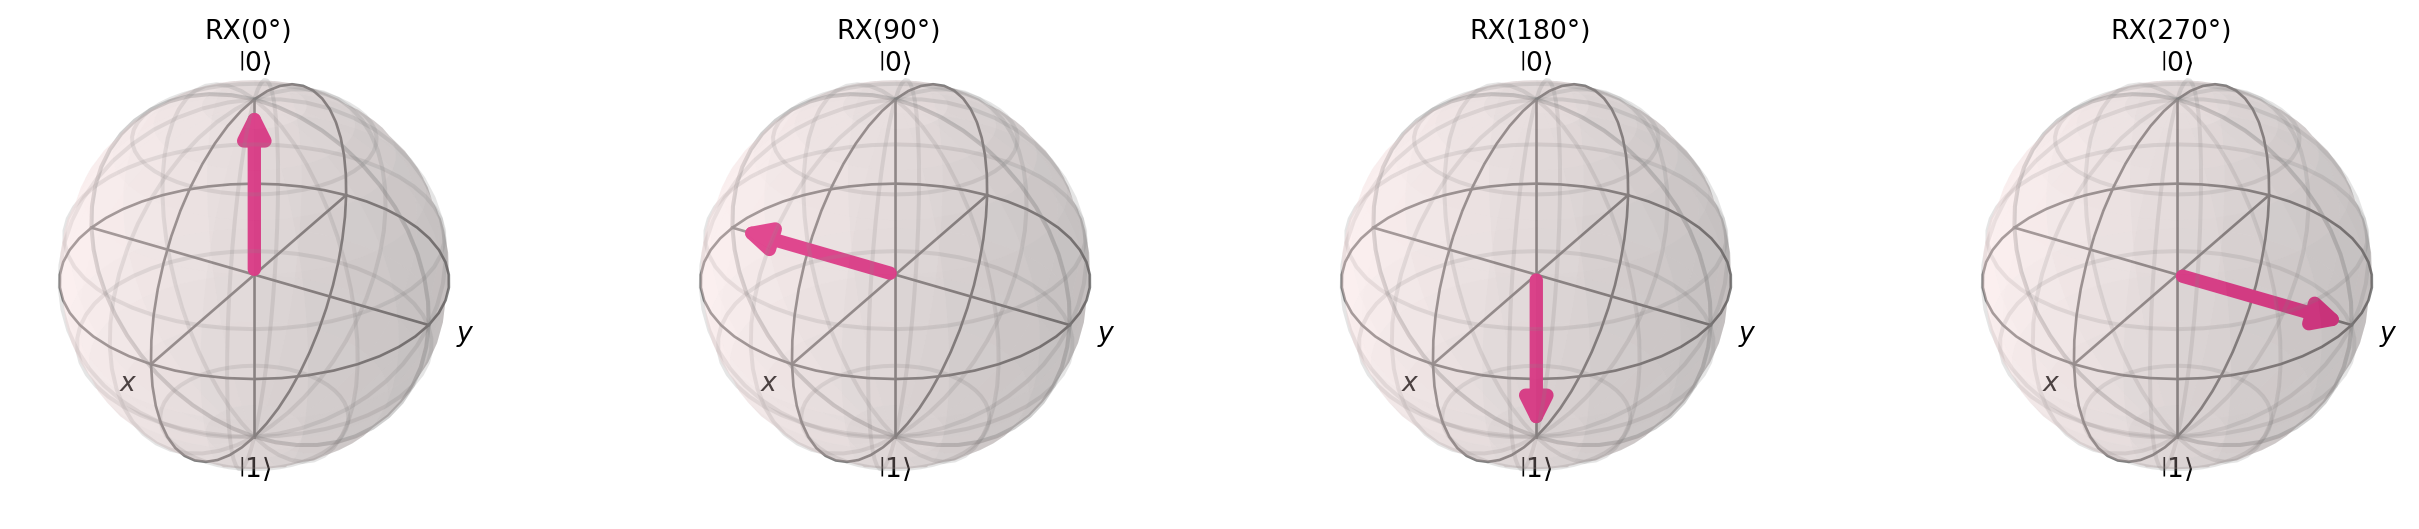


Observações:
  • RX rotaciona no plano YZ
  • RX(90°) cria superposição com números complexos
  • RX(180°) = X (porta NOT)


In [11]:
print("=" * 70)
print("PORTA RX: Rotação em torno do eixo X")
print("=" * 70)

angulos_rx = [0, np.pi/2, np.pi, 3*np.pi/2]
nomes_rx = ['0°', '90°', '180°', '270°']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': '3d'})

for i, (angulo, nome) in enumerate(zip(angulos_rx, nomes_rx)):
    qc = QuantumCircuit(1)
    qc.rx(angulo, 0)
    
    state = Statevector(qc)
    alpha = state.data[0]
    beta = state.data[1]
    
    print(f"\n{nome} (θ = {angulo:.4f} rad):")
    print(f"  RX({angulo:.4f})|0⟩ = {alpha}|0⟩ + {beta}|1⟩")
    print(f"  Probabilidades: P(0) = {abs(alpha)**2:.4f}, P(1) = {abs(beta)**2:.4f}")
    
    # Coordenadas de Bloch
    x = 2 * (alpha.conjugate() * beta).real
    y = 2 * (alpha.conjugate() * beta).imag
    z = abs(alpha)**2 - abs(beta)**2
    
    plot_bloch_vector([x, y, z], ax=axes[i], title=f'RX({nome})')

plt.subplots_adjust(wspace=0.4)
plt.show()

print("\n" + "=" * 70)
print("Observações:")
print("  • RX rotaciona no plano YZ")
print("  • RX(90°) cria superposição com números complexos")
print("  • RX(180°) = X (porta NOT)")
print("=" * 70)

In [12]:
import numpy as np

# Implementação manual das portas de rotação parametrizadas
def rx_gate(theta):
    """Porta RX(θ) - Rotação em torno do eixo X"""
    return np.array([
        [np.cos(theta/2), -1j*np.sin(theta/2)],
        [-1j*np.sin(theta/2), np.cos(theta/2)]
    ])

def ry_gate(theta):
    """Porta RY(θ) - Rotação em torno do eixo Y"""
    return np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2), np.cos(theta/2)]
    ])

def rz_gate(theta):
    """Porta RZ(θ) - Rotação em torno do eixo Z"""
    return np.array([
        [np.exp(-1j*theta/2), 0],
        [0, np.exp(1j*theta/2)]
    ])

# Estados básicos
ket_0 = np.array([[1], [0]])
ket_1 = np.array([[0], [1]])

print("=" * 70)
print("IMPLEMENTAÇÃO MANUAL DAS PORTAS DE ROTAÇÃO")
print("=" * 70)

# Testar RY com θ = π/2 (90° na Esfera de Bloch)
theta = np.pi / 2
print(f"\n🔹 Testando RY({theta:.4f}) em |0⟩:")
print(f"   Ângulo: π/2 = 90° na Esfera de Bloch")

RY = ry_gate(theta)
state_ry = RY.dot(ket_0)

print(f"\n   Matriz RY(π/2):")
print(f"   {RY[0]}")
print(f"   {RY[1]}")

print(f"\n   RY(π/2)|0⟩ = {state_ry[0][0]:.4f}|0⟩ + {state_ry[1][0]:.4f}|1⟩")
print(f"   Esperado: 1/√2|0⟩ + 1/√2|1⟩ = |+⟩")
print(f"   Probabilidades: P(0) = {abs(state_ry[0][0])**2:.4f}, P(1) = {abs(state_ry[1][0])**2:.4f}")

# Testar RZ com θ = π (180°)
print(f"\n🔹 Testando RZ(π) aplicado a |+⟩:")
print(f"   Ângulo: π = 180° na Esfera de Bloch")

# Primeiro criar |+⟩
H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])  # Porta Hadamard
ket_plus = H.dot(ket_0)

RZ = rz_gate(np.pi)
state_rz = RZ.dot(ket_plus.reshape(2,1))

print(f"\n   Estado inicial: |+⟩ = {ket_plus[0][0]:.4f}|0⟩ + {ket_plus[1][0]:.4f}|1⟩")
print(f"\n   Matriz RZ(π):")
print(f"   {RZ[0]}")
print(f"   {RZ[1]}")

# Simplificar a fase global e^(-iπ/2) = -i
phase_global = np.exp(-1j*np.pi/2)
state_rz_simplified = state_rz / phase_global

print(f"\n   RZ(π)|+⟩ = {state_rz[0][0]:.4f}|0⟩ + {state_rz[1][0]:.4f}|1⟩")
print(f"   Removendo fase global: ≈ {state_rz_simplified[0][0]:.4f}|0⟩ + {state_rz_simplified[1][0]:.4f}|1⟩")
print(f"   Esperado: 1/√2|0⟩ - 1/√2|1⟩ = |-⟩")
print(f"   ✅ RZ(π) = Z (porta Z é caso especial de RZ)")

# Testar RX com θ = π (180° = porta X)
print(f"\n🔹 Testando RX(π) em |0⟩:")
print(f"   Ângulo: π = 180° na Esfera de Bloch")

RX = rx_gate(np.pi)
state_rx = RX.dot(ket_0)

# Remover fase global -i
state_rx_real = state_rx / (-1j)

print(f"\n   Matriz RX(π):")
print(f"   {RX[0]}")
print(f"   {RX[1]}")

print(f"\n   RX(π)|0⟩ = {state_rx[0][0]}|0⟩ + {state_rx[1][0]}|1⟩")
print(f"   Removendo fase global: ≈ {state_rx_real[0][0]:.4f}|0⟩ + {state_rx_real[1][0]:.4f}|1⟩")
print(f"   Esperado: |1⟩")
print(f"   ✅ RX(π) = X (porta X é caso especial de RX)")

# Verificar casos especiais
print("\n" + "=" * 70)
print("CASOS ESPECIAIS (relação com portas fixas):")
print("=" * 70)

# Porta Z
Z = np.array([[1, 0], [0, -1]])
RZ_pi = rz_gate(np.pi)
# Remover fase global
RZ_pi_simplified = RZ_pi / np.exp(-1j*np.pi/2)
print(f"\nZ vs RZ(π):")
print(f"  Z =     {Z[0]}  {Z[1]}")
print(f"  RZ(π) = {RZ_pi_simplified[0]}  {RZ_pi_simplified[1]}")
print(f"  ✅ Equivalentes (a menos de fase global)")

# Porta S
S = np.array([[1, 0], [0, 1j]])
RZ_pi_2 = rz_gate(np.pi/2)
# Remover fase global
RZ_pi_2_simplified = RZ_pi_2 / np.exp(-1j*np.pi/4)
print(f"\nS vs RZ(π/2):")
print(f"  S =       {S[0]}  {S[1]}")
print(f"  RZ(π/2) = {RZ_pi_2_simplified[0]}  {RZ_pi_2_simplified[1]}")
print(f"  ✅ Equivalentes (a menos de fase global)")

# Porta X
X = np.array([[0, 1], [1, 0]])
RX_pi = rx_gate(np.pi)
RX_pi_simplified = RX_pi / (-1j)
print(f"\nX vs RX(π):")
print(f"  X =     {X[0]}  {X[1]}")
print(f"  RX(π) = {RX_pi_simplified[0]}  {RX_pi_simplified[1]}")
print(f"  ✅ Equivalentes (a menos de fase global)")

print("\n" + "=" * 70)
print("💡 CONCLUSÃO:")
print("   As portas fixas (X, Z, S, T) são casos especiais das portas")
print("   de rotação parametrizadas com ângulos específicos!")
print("=" * 70)

IMPLEMENTAÇÃO MANUAL DAS PORTAS DE ROTAÇÃO

🔹 Testando RY(1.5708) em |0⟩:
   Ângulo: π/2 = 90° na Esfera de Bloch

   Matriz RY(π/2):
   [ 0.70710678 -0.70710678]
   [0.70710678 0.70710678]

   RY(π/2)|0⟩ = 0.7071|0⟩ + 0.7071|1⟩
   Esperado: 1/√2|0⟩ + 1/√2|1⟩ = |+⟩
   Probabilidades: P(0) = 0.5000, P(1) = 0.5000

🔹 Testando RZ(π) aplicado a |+⟩:
   Ângulo: π = 180° na Esfera de Bloch

   Estado inicial: |+⟩ = 0.7071|0⟩ + 0.7071|1⟩

   Matriz RZ(π):
   [6.123234e-17-1.j 0.000000e+00+0.j]
   [0.000000e+00+0.j 6.123234e-17+1.j]

   RZ(π)|+⟩ = 0.0000-0.7071j|0⟩ + 0.0000+0.7071j|1⟩
   Removendo fase global: ≈ 0.7071-0.0000j|0⟩ + -0.7071+0.0000j|1⟩
   Esperado: 1/√2|0⟩ - 1/√2|1⟩ = |-⟩
   ✅ RZ(π) = Z (porta Z é caso especial de RZ)

🔹 Testando RX(π) em |0⟩:
   Ângulo: π = 180° na Esfera de Bloch

   Matriz RX(π):
   [6.123234e-17+0.j 0.000000e+00-1.j]
   [0.000000e+00-1.j 6.123234e-17+0.j]

   RX(π)|0⟩ = (6.123233995736766e-17+0j)|0⟩ + -1j|1⟩
   Removendo fase global: ≈ -0.0000+0.0000j|0⟩ + 1

CODIFICAÇÃO DE DADOS CLÁSSICOS EM QUBITS



Dado clássico: x = 0.00
  Ângulo: θ = 2π × 0.00 = 0.0000 rad (0.0°)
  Estado: 1.0000+0.0000j|0⟩ + 0.0000+0.0000j|1⟩
  P(medir 1) = 0.0000



Dado clássico: x = 0.25
  Ângulo: θ = 2π × 0.25 = 1.5708 rad (90.0°)
  Estado: 0.7071+0.0000j|0⟩ + 0.7071+0.0000j|1⟩
  P(medir 1) = 0.5000



Dado clássico: x = 0.50
  Ângulo: θ = 2π × 0.50 = 3.1416 rad (180.0°)
  Estado: 0.0000+0.0000j|0⟩ + 1.0000+0.0000j|1⟩
  P(medir 1) = 1.0000

Dado clássico: x = 0.75
  Ângulo: θ = 2π × 0.75 = 4.7124 rad (270.0°)
  Estado: -0.7071+0.0000j|0⟩ + 0.7071+0.0000j|1⟩
  P(medir 1) = 0.5000



Dado clássico: x = 1.00


  Ângulo: θ = 2π × 1.00 = 6.2832 rad (360.0°)
  Estado: -1.0000+0.0000j|0⟩ + 0.0000+0.0000j|1⟩
  P(medir 1) = 0.0000


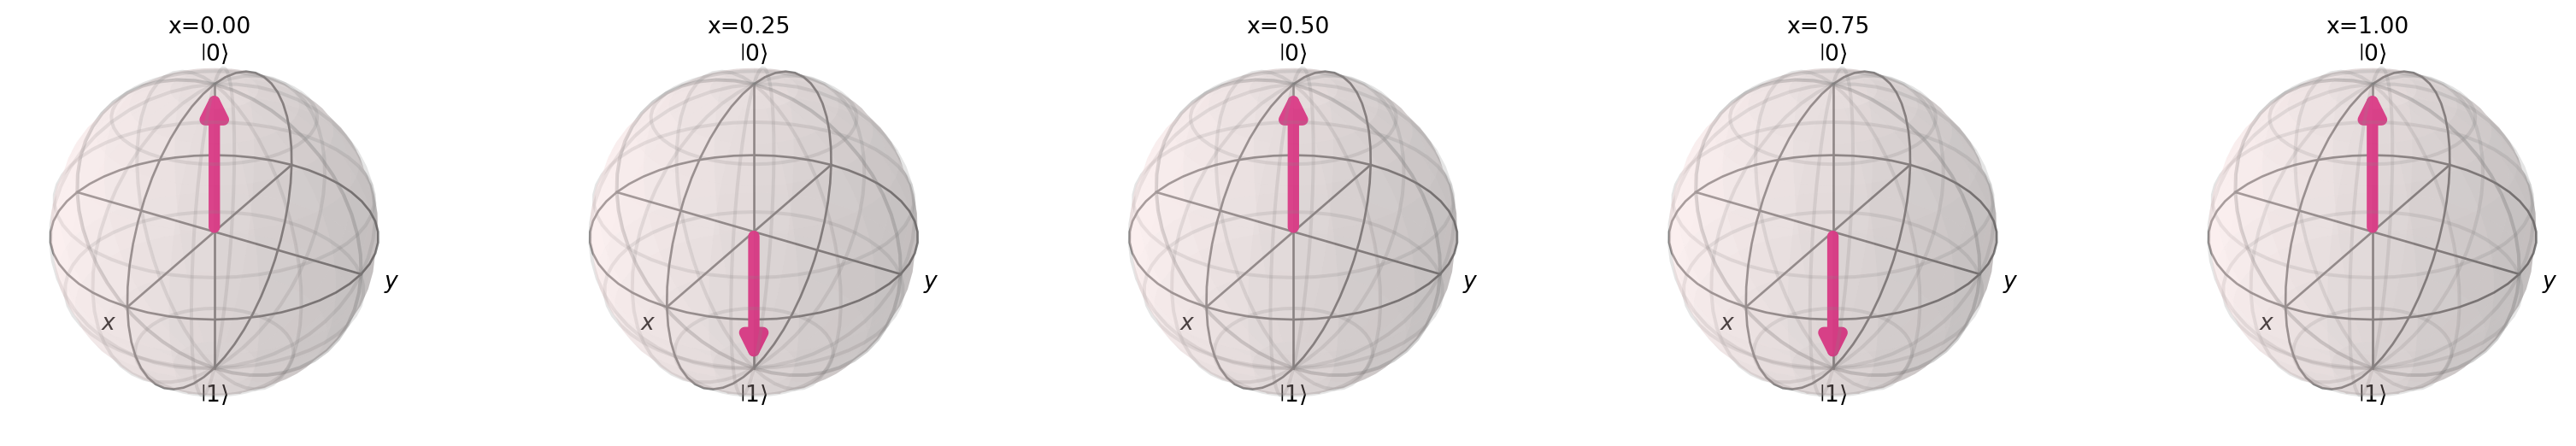


💡 Interpretação:
   Dados diferentes → Ângulos diferentes → Estados quânticos diferentes
   Assim, codificamos informação clássica em superposições quânticas!


In [13]:
# Importações necessárias para esta célula
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_vector
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("CODIFICAÇÃO DE DADOS CLÁSSICOS EM QUBITS")
print("=" * 70)

# Dados clássicos normalizados
dados_classicos = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={'projection': '3d'})

for i, x in enumerate(dados_classicos):
    # Mapear dado clássico para ângulo
    theta = 2 * np.pi * x
    
    # Criar circuito e aplicar RY
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    
    state = Statevector(qc)
    
    print(f"\nDado clássico: x = {x:.2f}")
    print(f"  Ângulo: θ = 2π × {x:.2f} = {theta:.4f} rad ({np.degrees(theta):.1f}°)")
    print(f"  Estado: {state.data[0]:.4f}|0⟩ + {state.data[1]:.4f}|1⟩")
    print(f"  P(medir 1) = {abs(state.data[1])**2:.4f}")
    
    # Visualizar
    theta_bloch = 2 * theta
    x_coord = np.sin(theta_bloch)
    y_coord = 0
    z_coord = np.cos(theta_bloch)
    
    plot_bloch_vector([x_coord, y_coord, z_coord], ax=axes[i], 
                     title=f'x={x:.2f}')

plt.subplots_adjust(wspace=0.4)
plt.show()

print("\n" + "=" * 70)
print("💡 Interpretação:")
print("   Dados diferentes → Ângulos diferentes → Estados quânticos diferentes")
print("   Assim, codificamos informação clássica em superposições quânticas!")
print("=" * 70)

In [14]:
# Implementação da porta CPHASE (Controlled-Phase)

def cphase_gate(theta):
    return np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, np.exp(1j * theta)]
    ])
    
# Testando a porta CPHASE com θ = π/2
theta = np.pi / 2
CPHASE = cphase_gate(theta)

# |11>
q_11 = np.array([
    [0],
    [0],
    [0],
    [1]
])

# Aplicando a porta CPHASE em |11>
novo_estado_cphase = np.dot(CPHASE, q_11)

print("\n--- Após aplicar a Porta CPHASE em |11> com θ=π/2 ---")
print(f"Esperamos e^(iπ/2)|11> = i|11>, obtivemos:\n{novo_estado_cphase}")
print("\n✅ A porta CPHASE funcionou como esperado! (aplicou a fase correta em |11>)")


--- Após aplicar a Porta CPHASE em |11> com θ=π/2 ---
Esperamos e^(iπ/2)|11> = i|11>, obtivemos:
[[0.000000e+00+0.j]
 [0.000000e+00+0.j]
 [0.000000e+00+0.j]
 [6.123234e-17+1.j]]

✅ A porta CPHASE funcionou como esperado! (aplicou a fase correta em |11>)


In [15]:
# Visualização do efeito da Porta CPHASE nas Esferas de Bloch
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [16]:
# Parâmetro da porta (já definido no notebook): θ = π/2
theta = np.pi / 2
CP = cphase_gate(theta)

print("=" * 70)
print("CRIANDO O ESTADO QUÂNTICO DE 2 QUBITS")
print("=" * 70)

# Definir os estados individuais
estado_qubit1 = 1/np.sqrt(2) * np.array([1, 1])   # |+⟩ para qubit 1
estado_qubit0 = np.array([0, 1])                  # |1⟩ para qubit 0

print("\n1️⃣ Estado do qubit 1 (controle):")
print(f"   |+⟩ = 1/√2 (|0⟩ + |1⟩)")
print(f"   Vetor: {estado_qubit1}")
print("   → Na esfera de Bloch: equador, direção +X")

print("\n2️⃣ Estado do qubit 0 (alvo):")
print(f"   |1⟩")
print(f"   Vetor: {estado_qubit0}")
print("   → Na esfera de Bloch: polo sul")

# Criar o estado composto usando produto tensorial (Kronecker)
state_before = np.kron(estado_qubit1, estado_qubit0)
sv_before = Statevector(state_before)

print("\n3️⃣ Estado composto (produto tensorial):")
print(f"   np.kron(|+⟩, |1⟩) = |+⟩ ⊗ |1⟩")
display(Markdown(r"$$= \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |1\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |11\rangle)$$"))

print("\n4️⃣ Vetor estado final (4 componentes):")
display(Markdown(r"""$$\begin{bmatrix}0 \\ \frac{1}{\sqrt{2}} \\ 0 \\ \frac{1}{\sqrt{2}} \end{bmatrix} \begin{array}{l} \leftarrow |00\rangle \text{ (qubit1=0, qubit0=0)} \\ \leftarrow |01\rangle \text{ (qubit1=0, qubit0=1)} ✓ \\ \leftarrow |10\rangle \text{ (qubit1=1, qubit0=0)} \\ \leftarrow |11\rangle \text{ (qubit1=1, qubit0=1)} ✓ \end{array}$$"""))

print("\n💡 Interpretação:")
print("   • Componentes |01⟩ e |11⟩ têm amplitude 1/√2 (50% de probabilidade cada)")
print("   • Qubit 0 está SEMPRE em |1⟩ (polo sul)")
print("   • Qubit 1 está em superposição |+⟩ (equador +X)")
print("=" * 70)

CRIANDO O ESTADO QUÂNTICO DE 2 QUBITS

1️⃣ Estado do qubit 1 (controle):
   |+⟩ = 1/√2 (|0⟩ + |1⟩)
   Vetor: [0.70710678 0.70710678]
   → Na esfera de Bloch: equador, direção +X

2️⃣ Estado do qubit 0 (alvo):
   |1⟩
   Vetor: [0 1]
   → Na esfera de Bloch: polo sul

3️⃣ Estado composto (produto tensorial):
   np.kron(|+⟩, |1⟩) = |+⟩ ⊗ |1⟩


$$= \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |1\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |11\rangle)$$


4️⃣ Vetor estado final (4 componentes):


$$\begin{bmatrix}0 \\ \frac{1}{\sqrt{2}} \\ 0 \\ \frac{1}{\sqrt{2}} \end{bmatrix} \begin{array}{l} \leftarrow |00\rangle \text{ (qubit1=0, qubit0=0)} \\ \leftarrow |01\rangle \text{ (qubit1=0, qubit0=1)} ✓ \\ \leftarrow |10\rangle \text{ (qubit1=1, qubit0=0)} \\ \leftarrow |11\rangle \text{ (qubit1=1, qubit0=1)} ✓ \end{array}$$


💡 Interpretação:
   • Componentes |01⟩ e |11⟩ têm amplitude 1/√2 (50% de probabilidade cada)
   • Qubit 0 está SEMPRE em |1⟩ (polo sul)
   • Qubit 1 está em superposição |+⟩ (equador +X)


Antes da CP (controle |+>, alvo |1>):


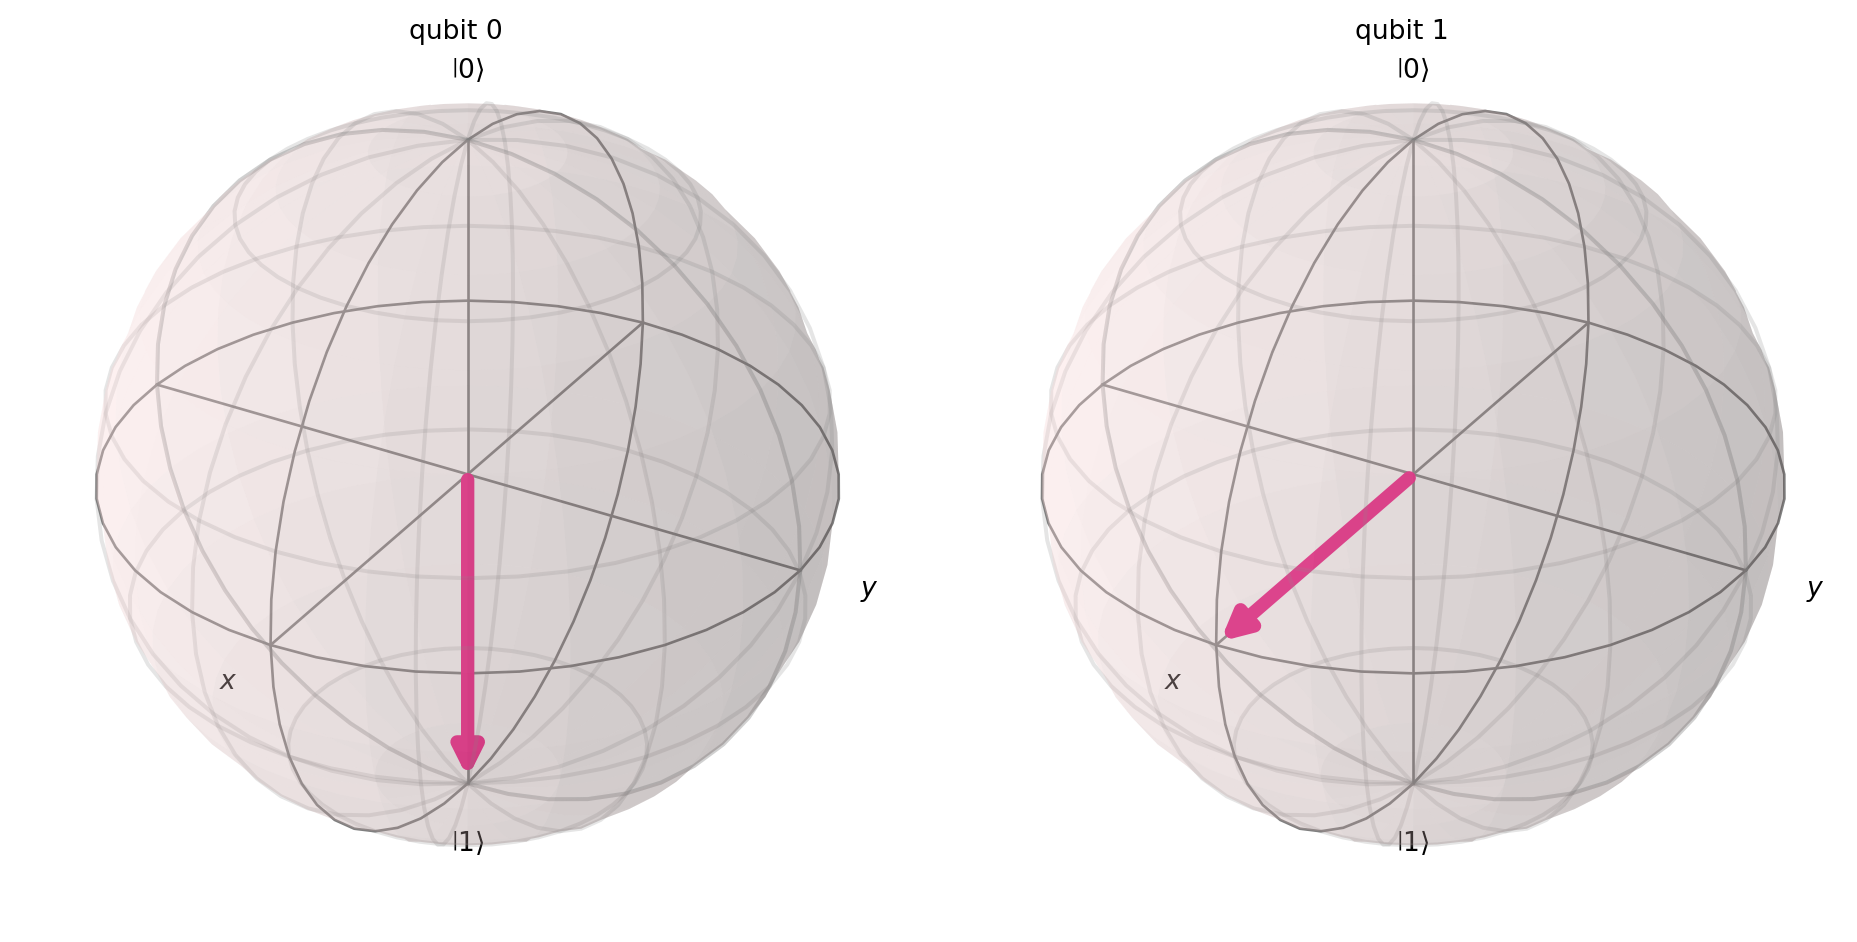

In [17]:
print("Antes da CP (controle |+>, alvo |1>):")
display(plot_bloch_multivector(sv_before))

Depois da CP (θ = π/2):


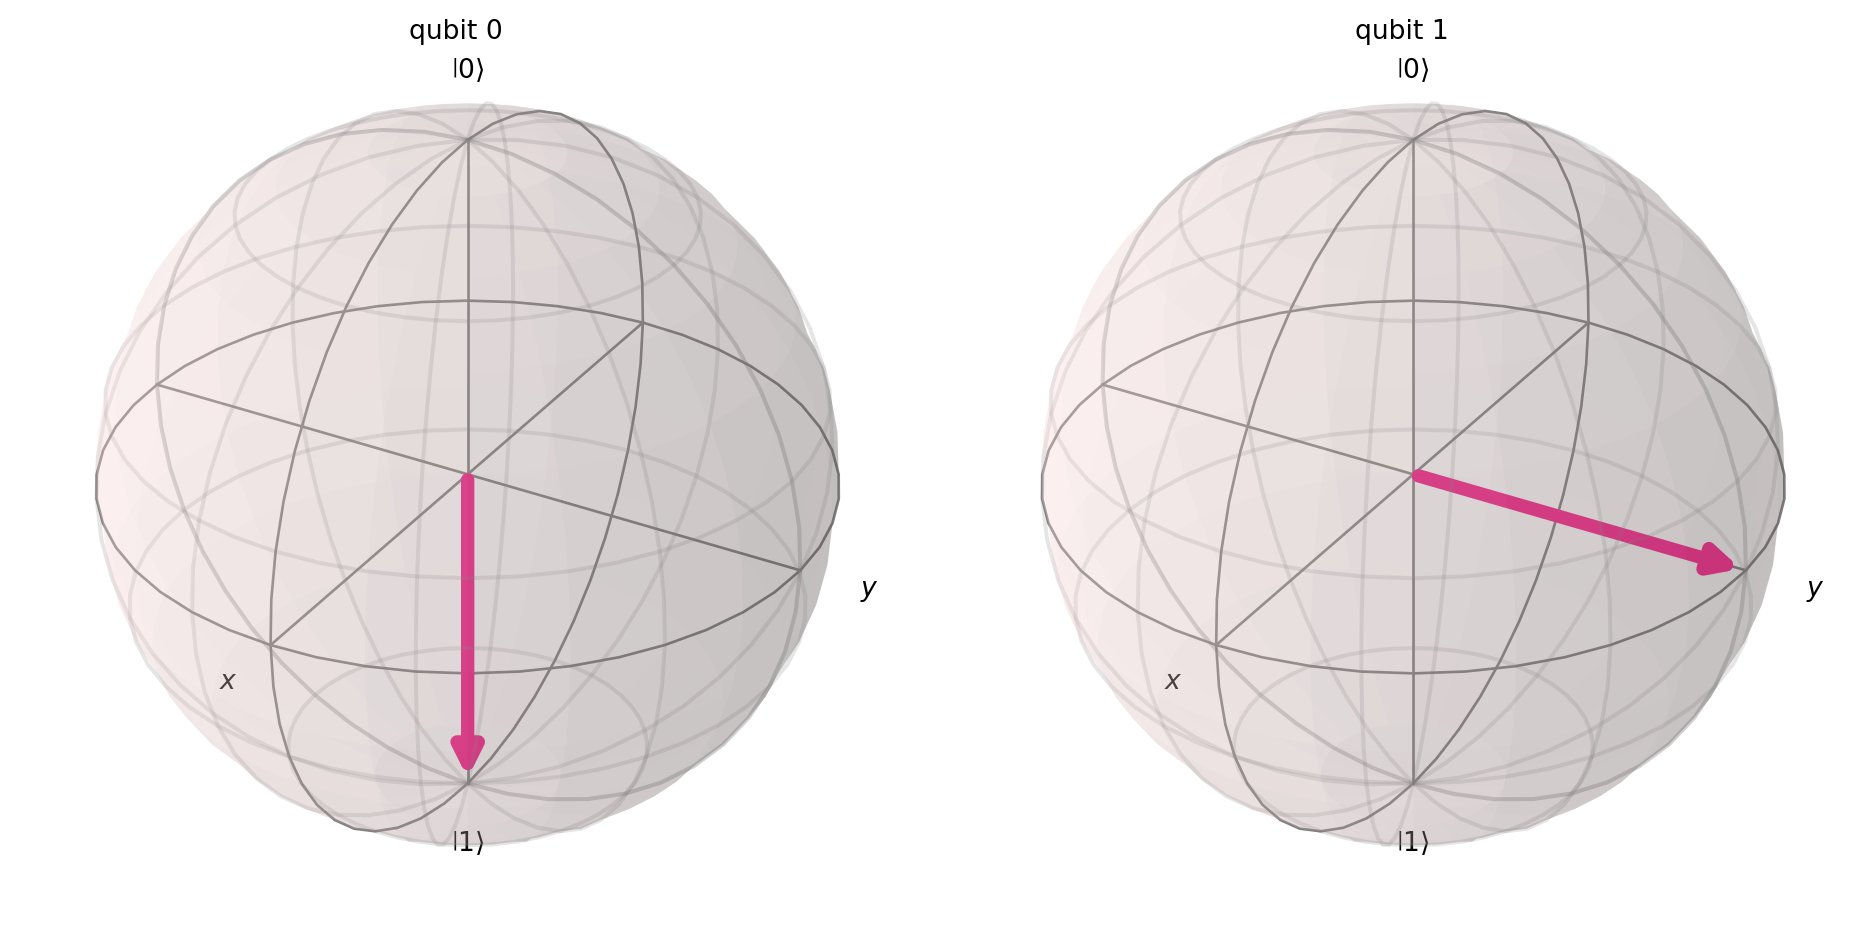

In [18]:
# Aplicar CPHASE
state_after = CP.dot(state_before.reshape(4, 1)).flatten()
sv_after = Statevector(state_after)

print("Depois da CP (θ = π/2):")
display(plot_bloch_multivector(sv_after))

In [19]:
# Análise numérica do estado reduzido do qubit alvo
psi_before = state_before.reshape((2, 2))    # formato (controle, alvo)
rho_target_before = np.conj(psi_before).T @ psi_before
psi_after = state_after.reshape((2, 2))
rho_target_after = np.conj(psi_after).T @ psi_after

def bloch_coords_from_rho(rho):
    r01 = rho[0,1]
    x = 2 * r01.real
    y = -2 * r01.imag
    z = rho[0,0].real - rho[1,1].real
    return x, y, z

x1, y1, z1 = bloch_coords_from_rho(rho_target_before)
x2, y2, z2 = bloch_coords_from_rho(rho_target_after)

print(f"\nQubit alvo - Bloch coords antes: x={x1:.3f}, y={y1:.3f}, z={z1:.3f}")
print(f"Qubit alvo - Bloch coords depois: x={x2:.3f}, y={y2:.3f}, z={z2:.3f}")

# Mostrar a mudança de fase na componente |11>
amp_11_before = state_before[3]
amp_11_after = state_after[3]
print(f"\nAmplitude |11> antes: {amp_11_before}, fase={np.angle(amp_11_before, deg=True):.2f}°")
print(f"Amplitude |11> depois: {amp_11_after}, fase={np.angle(amp_11_after, deg=True):.2f}°")


Qubit alvo - Bloch coords antes: x=0.000, y=-0.000, z=-1.000
Qubit alvo - Bloch coords depois: x=0.000, y=-0.000, z=-1.000

Amplitude |11> antes: 0.7071067811865475, fase=0.00°
Amplitude |11> depois: (4.329780281177466e-17+0.7071067811865475j), fase=90.00°


Circuito ANTES da porta CP:


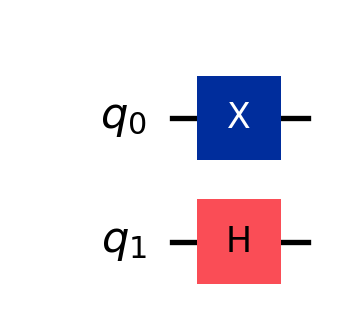

In [20]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np

# Criar um circuito com 2 qubits
qc = QuantumCircuit(2)

# Preparar o estado inicial: qubit 1 em |+⟩ e qubit 0 em |1⟩
qc.h(1)      # Hadamard no qubit 1 para criar |+⟩
qc.x(0)      # Porta X no qubit 0 para criar |1⟩

print("Circuito ANTES da porta CP:")
display(qc.draw('mpl'))

# Salvar estado antes da CP
estado_antes_qiskit = Statevector(qc)

Circuito DEPOIS da porta CP:


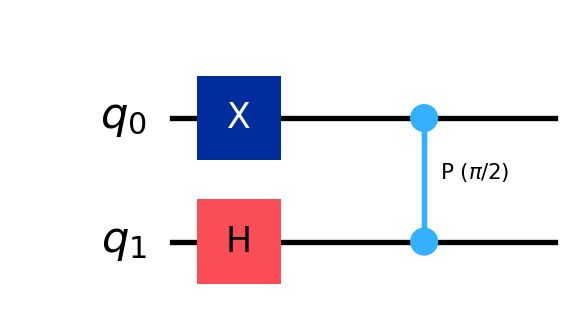

In [21]:
# Aplicar a porta CP (Controlled-Phase) com θ = π/2
theta = np.pi / 2
qc.cp(theta, 1, 0)  # Porta CP: controle=qubit1, alvo=qubit0

print("Circuito DEPOIS da porta CP:")
display(qc.draw('mpl'))

# Obter o estado final
estado_depois_qiskit = Statevector(qc)

In [22]:
# Comparar com o resultado NumPy anterior
print("="*70)
print("COMPARAÇÃO: NumPy vs Qiskit")
print("="*70)

# Formatação mais clara da comparação NumPy vs Qiskit
def state_markdown(vec, label):
    lines = [f"**{label}**  "]
    for idx, amp in enumerate(np.asarray(vec).flatten()):
        mag = abs(amp)
        ph = np.angle(amp, deg=True)
        lines.append(f"- |{idx:02b}> : amp = {mag:.6f} , fase = {ph:7.2f}° , valor = {amp}")
    return "  \n".join(lines)

display(Markdown("### 🔍 Comparação: NumPy vs Qiskit"))
display(Markdown(state_markdown(state_before, "Antes (NumPy)")))
display(Markdown(state_markdown(estado_antes_qiskit.data, "Antes (Qiskit)")))
maxdiff_before = np.max(np.abs(state_before - estado_antes_qiskit.data))
display(Markdown(f"**Diferença máxima (antes):** {maxdiff_before:.10e}"))

display(Markdown("<hr />"))

display(Markdown(state_markdown(state_after, "Depois (NumPy)")))
display(Markdown(state_markdown(estado_depois_qiskit.data, "Depois (Qiskit)")))
maxdiff_after = np.max(np.abs(state_after - estado_depois_qiskit.data))
display(Markdown(f"**Diferença máxima (depois):** {maxdiff_after:.10e}"))

if np.allclose(state_before, estado_antes_qiskit.data, atol=1e-10) and np.allclose(state_after, estado_depois_qiskit.data, atol=1e-10):
    display(Markdown("✅ **Resultados idênticos dentro da tolerância numérica (atol=1e-10).**"))
else:
    display(Markdown("⚠️ **Diferenças detectadas — verifique tolerâncias e fases.**"))

# Resumo focalizado na componente |11>
idx = 3
phase_before = np.angle(state_before[idx], deg=True)
phase_after = np.angle(state_after[idx], deg=True)
display(Markdown(
    f"**Componente |11>:**  \n"
    f"- NumPy: amp = {abs(state_before[idx]):.6f}, fase = {phase_before:7.2f}°  \n"
    f"- Qiskit: amp = {abs(estado_depois_qiskit.data[idx]):.6f}, fase = {phase_after:7.2f}°"
))

COMPARAÇÃO: NumPy vs Qiskit


### 🔍 Comparação: NumPy vs Qiskit

**Antes (NumPy)**    
- |00> : amp = 0.000000 , fase =    0.00° , valor = 0.0  
- |01> : amp = 0.707107 , fase =    0.00° , valor = 0.7071067811865475  
- |10> : amp = 0.000000 , fase =    0.00° , valor = 0.0  
- |11> : amp = 0.707107 , fase =    0.00° , valor = 0.7071067811865475

**Antes (Qiskit)**    
- |00> : amp = 0.000000 , fase =    0.00° , valor = 0j  
- |01> : amp = 0.707107 , fase =    0.00° , valor = (0.7071067811865475+0j)  
- |10> : amp = 0.000000 , fase =    0.00° , valor = 0j  
- |11> : amp = 0.707107 , fase =    0.00° , valor = (0.7071067811865475+0j)

**Diferença máxima (antes):** 0.0000000000e+00

...

**Depois (NumPy)**    
- |00> : amp = 0.000000 , fase =    0.00° , valor = 0j  
- |01> : amp = 0.707107 , fase =    0.00° , valor = (0.7071067811865475+0j)  
- |10> : amp = 0.000000 , fase =    0.00° , valor = 0j  
- |11> : amp = 0.707107 , fase =   90.00° , valor = (4.329780281177466e-17+0.7071067811865475j)

**Depois (Qiskit)**    
- |00> : amp = 0.000000 , fase =    0.00° , valor = 0j  
- |01> : amp = 0.707107 , fase =    0.00° , valor = (0.7071067811865475+0j)  
- |10> : amp = 0.000000 , fase =    0.00° , valor = 0j  
- |11> : amp = 0.707107 , fase =   90.00° , valor = (4.329780281177466e-17+0.7071067811865475j)

**Diferença máxima (depois):** 0.0000000000e+00

✅ **Resultados idênticos dentro da tolerância numérica (atol=1e-10).**

**Componente |11>:**  
- NumPy: amp = 0.707107, fase =    0.00°  
- Qiskit: amp = 0.707107, fase =   90.00°

Estado final (após CP) usando Qiskit:


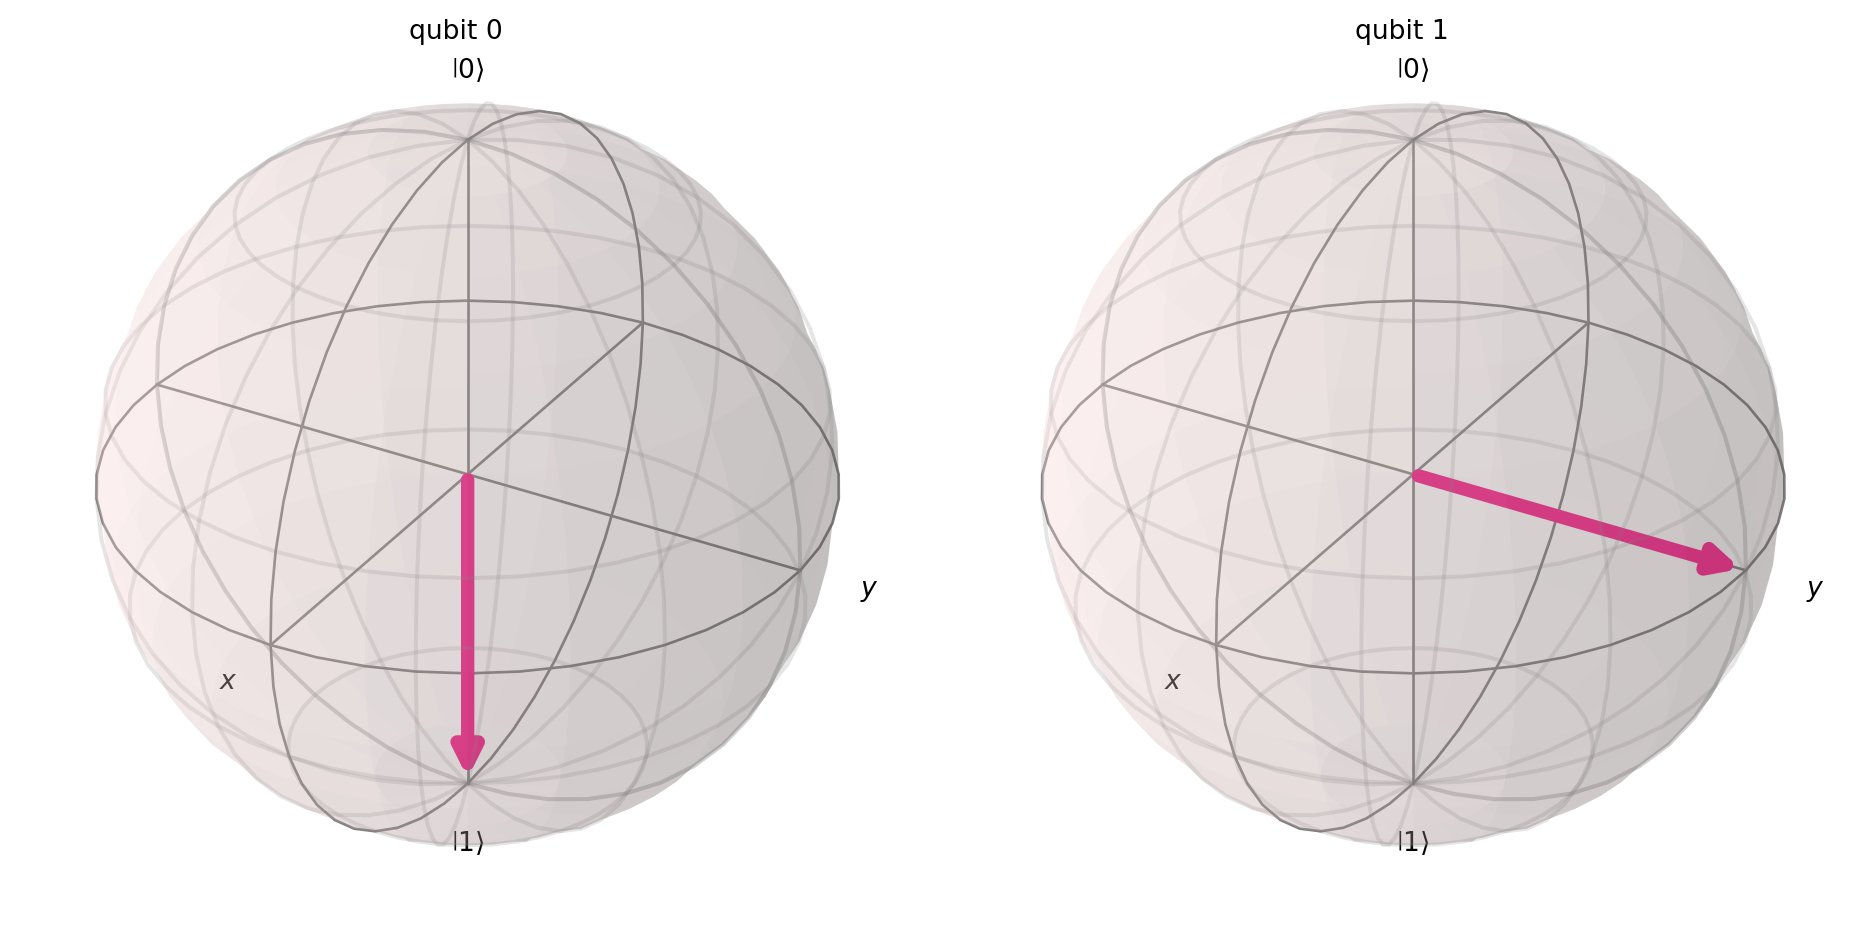


Amplitudes do estado final:
  |01⟩: amplitude = 0.7071, fase =    0.00°
  |11⟩: amplitude = 0.7071, fase =   90.00°


In [23]:
# Visualizar o estado final nas esferas de Bloch
print("Estado final (após CP) usando Qiskit:")
display(plot_bloch_multivector(estado_depois_qiskit))

# Mostrar as amplitudes e fases
print("\nAmplitudes do estado final:")
for i, amp in enumerate(estado_depois_qiskit.data):
    if abs(amp) > 1e-10:
        fase_graus = np.angle(amp, deg=True)
        print(f"  |{i:02b}⟩: amplitude = {abs(amp):.4f}, fase = {fase_graus:7.2f}°")